# **Portfolio Theory for Pit Stop & Tire Strategy - Markowitz Mean-Variance / Black-Litterman Portfolio Optimization**

In finance, portfolio optimization balances expected return against portfolio risk (volatility) given covariance between assets. Instead of treating pit window strategy as a fixed deterministic path, frame **tire choice and stint lengths as an asset allocation problem**.

- **Assets:** Tire compounds (Soft, Medium, Hard, Wet) over target stint windows.
- **Return:** Expected lap time / race duration minimization.
- **Risk/Covariance Matrix:** Uncertainty in lap times driven by tire degradation, track evolution, and traffic probability.

Use **GARCH (Generalized Autoregressive Conditional Heteroskedasticity)** or **Kalman Filters** combined with **LightGBM / XGBoost** to dynamically predict time-series volatility (tire degradation variance) per lap rather than assuming constant variance. A dynamic strategy tool that adjusts pit windows based on real-time track risk regimes, treating traffic traffic dynamic density as downside risk (like drawdowns)

- The core statistical framework uses GARCH models or Kalman Filters to capture time-varying lap-time volatility, modeling baseline driver pace alongside tire wear noise. This dynamic variance prediction feeds into a LightGBM or XGBoost pipeline, providing the risk parameters required for a Markowitz mean-variance portfolio optimization engine
- Building this requires extracting lap times, tire compound stints, track temperature, and sector telemetry across recent F1 seasons using the FastF1 Python package. You then process these time series into rolling windows, isolating residual lap-time variance with GARCH before training gradient boosted trees to predict future lap degradation and traffic risk
- The primary output is a real-time risk-return efficiency frontier that calculates optimal stint lengths and pit windows dynamically every lap. By balancing expected lap times against traffic density and tire degradation variance, the system provides a probabilistic strategy matrix to minimize total race time under risk
- **For Historical Macro Modeling / Fast Prototyping:** Using the **Kaggle dataset** (`lap_times.csv` + `pit_stops.csv`). You can calculate rolling variance on lap time residuals, model gap dynamics, and simulate basic portfolio allocation without needing compound labels (treating the stint as an generic aging asset).
- **For Compound Degradation & Portfolio Optimization:** Merge the Kaggle tables with **`FastF1`** data for seasons 2018–2026. `FastF1` supplies the exact tire compounds (`Compound`, `TyreLife`), weather time-series, and sector splits necessary to build the full Markowitz tire portfolio covariance matrix.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', palette='muted')

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv
/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv
/kaggle/input/datasets/rohanrao/formula

In [2]:
# Install packages that may not be pre-installed in every environment.
# Soft-fails when Kaggle Internet is OFF (pip DNS errors) so the notebook can continue.
# On Kaggle: Settings → Notebook → Internet → On  (needed only if a package is missing)
import subprocess
import sys

def ensure_package(pkg, import_name=None, required=False):
    name = import_name or pkg
    try:
        __import__(name)
        print(f'OK  {name} (already installed)')
        return True
    except ImportError:
        pass

    try:
        subprocess.check_call(
            [sys.executable, '-m', 'pip', 'install', '-q', pkg],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.STDOUT,
        )
        __import__(name)
        print(f'OK  {name} (installed via pip)')
        return True
    except Exception as exc:
        level = 'REQUIRED' if required else 'optional'
        print(f'SKIP {name} [{level}] — install failed ({type(exc).__name__}). '
              f'If you need it, enable Internet in Kaggle notebook settings.')
        return False

# fastf1: optional on Kaggle (OpenF1 path is preferred; FastF1 live API is blocked anyway)
# xgboost: optional (pace model uses LightGBM)
# arch + lightgbm: needed for GARCH + pace model
_deps = {}
_deps['fastf1'] = ensure_package('fastf1', 'fastf1', required=False)
_deps['arch'] = ensure_package('arch', 'arch', required=True)
_deps['lightgbm'] = ensure_package('lightgbm', 'lightgbm', required=True)
_deps['xgboost'] = ensure_package('xgboost', 'xgboost', required=False)

missing_required = [k for k, ok in _deps.items() if not ok and k in {'arch', 'lightgbm'}]
if missing_required:
    print('WARNING: missing required packages:', ', '.join(missing_required))
    print('Enable Internet (Kaggle sidebar → Notebook options → Internet) and re-run this cell.')
else:
    print('Dependency check complete.')


OK  fastf1 (installed via pip)
OK  arch (installed via pip)
OK  lightgbm (already installed)
OK  xgboost (already installed)
Dependency check complete.


In [3]:
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Resolve data directory: Kaggle input path first, then kagglehub cache, then local fallback
KAGGLE_INPUT = Path('/kaggle/input')
LOCAL_DATA = Path('data')

def resolve_data_dir():
    if KAGGLE_INPUT.exists():
        candidates = [p for p in KAGGLE_INPUT.rglob('lap_times.csv')]
        if candidates:
            return candidates[0].parent
    try:
        cache_path = Path(kagglehub.dataset_download('jtrotman/formula-1-race-data'))
        if (cache_path / 'lap_times.csv').exists():
            return cache_path
        nested = list(cache_path.rglob('lap_times.csv'))
        if nested:
            return nested[0].parent
    except Exception as exc:
        print(f'kagglehub download skipped: {exc}')
    if (LOCAL_DATA / 'lap_times.csv').exists():
        return LOCAL_DATA
    raise FileNotFoundError('Could not locate lap_times.csv. Place Ergast CSVs in data/ or run on Kaggle.')

DATA_DIR = resolve_data_dir()
print(f'Using data directory: {DATA_DIR}')

# Core Kaggle tables used for historical macro modeling and pit-stop penalties
lap_times_data = pd.read_csv(DATA_DIR / 'lap_times.csv')
pit_stops_data = pd.read_csv(DATA_DIR / 'pit_stops.csv')
races_data = pd.read_csv(DATA_DIR / 'races.csv')
drivers_data = pd.read_csv(DATA_DIR / 'drivers.csv')
results_data = pd.read_csv(DATA_DIR / 'results.csv')

print('lap_times_data:', lap_times_data.shape)
print('pit_stops_data:', pit_stops_data.shape)
print('races_data:', races_data.shape)

Using data directory: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
lap_times_data: (589081, 6)
pit_stops_data: (11371, 7)
races_data: (1125, 18)


In [4]:
# Load compound-level lap data: OpenF1 (cloud-friendly) -> FastF1 cache (input only) -> Kaggle fallback
import socket
import time
import shutil
import requests

COMPOUND_DATA_SOURCE = None
compound_laps_data = pd.DataFrame()
IS_KAGGLE = Path('/kaggle/working').exists()

def has_internet(host='8.8.8.8', port=53, timeout=3):
    try:
        socket.create_connection((host, port), timeout=timeout)
        return True
    except OSError:
        return False

INTERNET_AVAILABLE = has_internet()
print(f'Running on Kaggle: {IS_KAGGLE}')
print(f'Internet available: {INTERNET_AVAILABLE}')

def is_valid_fastf1_cache(cache_path):
    """Only treat a cache as valid if it has parsed session files, not just a sqlite stub."""
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return False
    year_dirs = [d for d in cache_path.iterdir() if d.is_dir() and d.name.isdigit()]
    if not year_dirs:
        return False
    return any(year_dir.rglob('*.ff1pkl') for year_dir in year_dirs)

def try_load_fastf1_cache():
    # On Kaggle, only trust a user-attached cache under /kaggle/input (not partial working-dir caches)
    import fastf1
    cache_candidates = []
    if Path('/kaggle/input').exists():
        for p in Path('/kaggle/input').rglob('fastf1_http_cache.sqlite'):
            if is_valid_fastf1_cache(p.parent):
                cache_candidates.append(p.parent)
    if not IS_KAGGLE:
        local_cache = Path('f1cache')
        if is_valid_fastf1_cache(local_cache):
            cache_candidates.append(local_cache)
    if not cache_candidates:
        print('No complete FastF1 cache found (skipping FastF1 cache path).')
        return pd.DataFrame()

    try:
        working_cache = Path('/kaggle/working/f1cache') if IS_KAGGLE else Path('f1cache')
        if working_cache.exists():
            shutil.rmtree(working_cache)
        working_cache.mkdir(parents=True, exist_ok=True)

        src = cache_candidates[0]
        for item in src.iterdir():
            dest = working_cache / item.name
            if item.is_dir():
                shutil.copytree(item, dest)
            else:
                shutil.copy2(item, dest)

        fastf1.Cache.enable_cache(str(working_cache))
        fastf1.Cache.offline_mode(True)

        frames = []
        def build_fastf1_event_list():
            """All grand prix names per season from FastF1 schedule."""
            import fastf1
            events = []
            for year in range(YEAR_MIN, YEAR_MAX + 1):
                try:
                    schedule = fastf1.get_event_schedule(year)
                    # RoundNumber > 0 excludes testing; EventName works with get_session
                    for _, row in schedule[schedule['RoundNumber'] > 0].iterrows():
                        gp = row['EventName'].replace(' Grand Prix', '')
                        events.append((year, gp))
                except Exception as exc:
                    print(f'FastF1 schedule unavailable for {year}: {exc}')
            return events
        FASTF1_EVENTS = build_fastf1_event_list()
        print(f'FastF1 events to try from cache: {len(FASTF1_EVENTS)}')
        for year, gp in FASTF1_EVENTS:
            try:
                session = fastf1.get_session(year, gp, 'R')
                session.load(laps=True, telemetry=False, weather=False, messages=False)
                if session.laps is not None and not session.laps.empty:
                    laps = session.laps.copy()
                    laps['Season'] = year
                    laps['GrandPrix'] = gp
                    laps['TrackTemp'] = 30.0
                    laps['AirTemp'] = 25.0
                    frames.append(laps)
                    print(f'FastF1 cache hit: {year} {gp} ({len(laps)} laps)')
            except Exception as exc:
                print(f'FastF1 cache miss for {year} {gp}: {exc}')
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    except Exception as exc:
        print(f'FastF1 cache load failed safely: {exc}')
        return pd.DataFrame()

# ── Coverage config (edit these) ──────────────────────────────────────────
YEAR_MIN = 2020          # earliest season for modeling
YEAR_MAX = 2025          # latest season (set to 2026 when available)
OPENF1_YEAR_MIN = 2023   # OpenF1 has compound/stint data from ~2023
USE_OPENF1_AUTO_DISCOVER = True   # pull all race sessions from API
MAX_OPENF1_RACES = None  # None = all; or e.g. 40 to cap for testing

# Optional manual overrides (merged with auto-discovered events)
MANUAL_OPENF1_EVENTS = [
    # (2023, 'Monaco'),
    # (2024, 'Singapore'),
]

COMPOUND_CACHE_PATH = Path('data/compound_laps_cache.parquet')
REFRESH_COMPOUND_CACHE = False  # set True to force re-download

def discover_openf1_race_sessions(year_min, year_max):
    """Fetch all Race session_keys from OpenF1 for each year."""
    base = 'https://api.openf1.org/v1'
    sessions = []
    for year in range(year_min, year_max + 1):
        resp = requests.get(
            f'{base}/sessions',
            params={'year': year, 'session_name': 'Race'},
            timeout=30,
        )
        resp.raise_for_status()
        for s in resp.json():
            gp = s.get('circuit_short_name') or s.get('location') or 'Unknown'
            sessions.append({
                'session_key': s['session_key'],
                'year': year,
                'gp': gp,
                'country': s.get('country_name', ''),
            })
        time.sleep(0.3)
    return sessions

def build_openf1_event_list():
    events = []
    if USE_OPENF1_AUTO_DISCOVER:
        discovered = discover_openf1_race_sessions(OPENF1_YEAR_MIN, YEAR_MAX)
        events = [(d['year'], d['gp'], d['session_key']) for d in discovered]
        print(f'OpenF1 auto-discovered {len(events)} race sessions ({OPENF1_YEAR_MIN}–{YEAR_MAX})')
    # add manual events (dedupe by session_key or year+gp)
    seen = {(y, g) for y, g, *_ in events}
    for year, gp in MANUAL_OPENF1_EVENTS:
        if (year, gp) not in seen:
            events.append((year, gp, None))
    if MAX_OPENF1_RACES is not None:
        events = events[:MAX_OPENF1_RACES]
    return events

def load_openf1_race(year, location_keyword, session_key=None):
  """Load one race from OpenF1. Pass session_key when known (faster, no ambiguity)."""
  base = 'https://api.openf1.org/v1'

  if session_key is None:
      resp = requests.get(
          f'{base}/sessions',
          params={'year': year, 'session_name': 'Race'},
          timeout=30,
      )
      resp.raise_for_status()
      matches = [
          s for s in resp.json()
          if location_keyword.lower() in s.get('location', '').lower()
          or location_keyword.lower() in s.get('circuit_short_name', '').lower()
      ]
      if not matches:
          raise ValueError(f'No OpenF1 race session found for {year} {location_keyword}')
      session_key = matches[0]['session_key']

  time.sleep(0.4)
  laps = pd.DataFrame(requests.get(f'{base}/laps', params={'session_key': session_key}, timeout=60).json())
  time.sleep(0.4)
  stints = pd.DataFrame(requests.get(f'{base}/stints', params={'session_key': session_key}, timeout=60).json())
  time.sleep(0.4)
  drivers = pd.DataFrame(requests.get(f'{base}/drivers', params={'session_key': session_key}, timeout=30).json())

  if laps.empty or stints.empty:
      raise ValueError(f'OpenF1 returned empty laps/stints for session {session_key}')

  laps = laps.rename(columns={'lap_number': 'LapNumber', 'lap_duration': 'lap_time_s'})
  laps = laps.dropna(subset=['lap_time_s'])

  rows = []
  for _, lap in laps.iterrows():
      stint_match = stints[
          (stints['driver_number'] == lap['driver_number'])
          & (lap['LapNumber'] >= stints['lap_start'])
          & (lap['LapNumber'] <= stints['lap_end'])
      ]
      if stint_match.empty:
          continue
      stint = stint_match.iloc[0]
      rows.append({
          'LapNumber': int(lap['LapNumber']),
          'lap_time_s': float(lap['lap_time_s']),
          'Compound': str(stint['compound']).upper(),
          'TyreLife': int(lap['LapNumber'] - stint['lap_start'] + stint.get('tyre_age_at_start', 1)),
          'Driver': str(lap['driver_number']),
          'Position': lap.get('position'),
          'Season': year,
          'GrandPrix': location_keyword,
          'session_key': session_key,
          'TrackTemp': 30.0,
          'AirTemp': 25.0,
      })

  df = pd.DataFrame(rows)
  if not drivers.empty and 'name_acronym' in drivers.columns:
      code_map = drivers.set_index('driver_number')['name_acronym'].astype(str).to_dict()
      df['Driver'] = df['Driver'].astype(int).map(lambda d: code_map.get(d, str(d)))
  return df

def try_load_openf1():
    if not INTERNET_AVAILABLE:
        return pd.DataFrame()

    # Return cached data if available
    if COMPOUND_CACHE_PATH.exists() and not REFRESH_COMPOUND_CACHE:
        cached = pd.read_parquet(COMPOUND_CACHE_PATH)
        cached = cached[(cached['Season'] >= OPENF1_YEAR_MIN) & (cached['Season'] <= YEAR_MAX)]
        print(f'Loaded {len(cached):,} laps from cache: {COMPOUND_CACHE_PATH}')
        return cached

    frames = []
    for event in OPENF1_EVENTS:
        # supports (year, gp) or (year, gp, session_key)
        if len(event) == 3:
            year, gp, session_key = event
        else:
            year, gp = event
            session_key = None
        try:
            df = load_openf1_race(year, gp, session_key=session_key)
            frames.append(df)
            print(f'OpenF1 loaded: {year} {gp} ({len(df)} laps)')
        except Exception as exc:
            print(f'OpenF1 failed for {year} {gp}: {exc}')

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    COMPOUND_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    out.to_parquet(COMPOUND_CACHE_PATH, index=False)
    print(f'Saved {len(out):,} laps to {COMPOUND_CACHE_PATH}')
    return out


OPENF1_EVENTS = build_openf1_event_list()
print(f'OpenF1 events to load: {len(OPENF1_EVENTS)}')

def try_load_fastf1_live():
    # F1 blocks datacenter IPs; skip entirely on Kaggle to avoid corrupt partial caches
    if IS_KAGGLE or not INTERNET_AVAILABLE:
        if IS_KAGGLE:
            print('Skipping FastF1 live API on Kaggle (F1 blocks cloud/datacenter IPs).')
        return pd.DataFrame()
    import fastf1
    cache_dir = Path('f1cache')
    cache_dir.mkdir(parents=True, exist_ok=True)
    fastf1.Cache.enable_cache(str(cache_dir))
    fastf1.set_log_level('ERROR')

    frames = []
    for year, gp in FASTF1_EVENTS:
        try:
            session = fastf1.get_session(year, gp, 'R')
            session.load(laps=True, telemetry=False, weather=False, messages=False)
            if session.laps is not None and not session.laps.empty:
                laps = session.laps.copy()
                laps['Season'] = year
                laps['GrandPrix'] = gp
                laps['TrackTemp'] = 30.0
                laps['AirTemp'] = 25.0
                frames.append(laps)
                print(f'FastF1 live API: {year} {gp} ({len(laps)} laps)')
        except Exception:
            print('FastF1 live API unavailable on this network.')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# On Kaggle, prefer OpenF1 first (FastF1 live API is blocked; working-dir caches are often partial)
if IS_KAGGLE:
    compound_laps_data = try_load_openf1()
    if not compound_laps_data.empty:
        COMPOUND_DATA_SOURCE = 'openf1'
    else:
        compound_laps_data = try_load_fastf1_cache()
        if not compound_laps_data.empty:
            COMPOUND_DATA_SOURCE = 'fastf1_cache'
        else:
            COMPOUND_DATA_SOURCE = 'kaggle_fallback'
            print('No compound API data available. Step 1 will use Kaggle Ergast fallback.')
else:
    compound_laps_data = try_load_fastf1_cache()
    if not compound_laps_data.empty:
        COMPOUND_DATA_SOURCE = 'fastf1_cache'
    else:
        compound_laps_data = try_load_openf1()
        if not compound_laps_data.empty:
            COMPOUND_DATA_SOURCE = 'openf1'
        else:
            compound_laps_data = try_load_fastf1_live()
            if not compound_laps_data.empty:
                COMPOUND_DATA_SOURCE = 'fastf1_live'
            else:
                COMPOUND_DATA_SOURCE = 'kaggle_fallback'
                print('No compound API data available. Step 1 will use Kaggle Ergast fallback.')

fastf1_laps_data = compound_laps_data.copy()
if not fastf1_laps_data.empty and 'LapTime' in fastf1_laps_data.columns:
    fastf1_laps_data['lap_time_s'] = fastf1_laps_data['LapTime'].dt.total_seconds()

print(f'Compound data source: {COMPOUND_DATA_SOURCE}')
print('compound_laps_data:', compound_laps_data.shape)

Running on Kaggle: True
Internet available: True
OpenF1 auto-discovered 71 race sessions (2023–2025)
OpenF1 events to load: 71
OpenF1 loaded: 2023 Sakhir (1055 laps)
OpenF1 loaded: 2023 Jeddah (942 laps)
OpenF1 loaded: 2023 Melbourne (993 laps)
OpenF1 loaded: 2023 Baku (959 laps)
OpenF1 loaded: 2023 Miami (1138 laps)
OpenF1 failed for 2023 Imola: If using all scalar values, you must pass an index
OpenF1 loaded: 2023 Monte Carlo (1513 laps)
OpenF1 loaded: 2023 Catalunya (1310 laps)
OpenF1 loaded: 2023 Montreal (1315 laps)
OpenF1 failed for 2023 Spielberg: If using all scalar values, you must pass an index
OpenF1 failed for 2023 Silverstone: If using all scalar values, you must pass an index
OpenF1 failed for 2023 Hungaroring: If using all scalar values, you must pass an index
OpenF1 failed for 2023 Spa-Francorchamps: If using all scalar values, you must pass an index
OpenF1 failed for 2023 Zandvoort: If using all scalar values, you must pass an index
OpenF1 failed for 2023 Monza: If usi

## Exploratory Data Analysis

The following cells inspect structure, distributions, missingness, pit-stop behaviour, stint aging, and cross-table relationships. Each code cell is followed by a plain-English interpretation

In [5]:
display(pd.DataFrame({
    'table': ['lap_times', 'pit_stops', 'races'],
    'rows': [len(lap_times_data), len(pit_stops_data), len(races_data)],
    'columns': [lap_times_data.shape[1], pit_stops_data.shape[1], races_data.shape[1]],
}))

print('lap_times_data head')
display(lap_times_data.head())
print('pit_stops_data head')
display(pit_stops_data.head())

if not fastf1_laps_data.empty:
    compound_cols = [c for c in ['Compound', 'TyreLife', 'LapTime', 'Driver'] if c in fastf1_laps_data.columns]
    display(fastf1_laps_data[compound_cols].head())

,table,rows,columns
0,lap_times,589081,6
1,pit_stops,11371,7
2,races,1125,18


lap_times_data head


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


pit_stops_data head


,raceId,driverId,stop,lap,time,duration,milliseconds
0,841,153,1,1,17:05:23,26.898,26898
1,841,30,1,1,17:05:52,25.021,25021
2,841,17,1,11,17:20:48,23.426,23426
3,841,4,1,12,17:22:34,23.251,23251
4,841,13,1,13,17:24:10,23.842,23842


,Compound,TyreLife,Driver
0,SOFT,3,VER
1,SOFT,3,PER
2,SOFT,0,LEC
3,SOFT,3,OCO
4,SOFT,3,HUL


The Kaggle tables follow the Ergast relational schema. `lap_times_data` stores one row per driver per lap with millisecond timing; `pit_stops_data` records stop number, lap, and duration. `races_data` links `raceId` to season and circuit. FastF1 adds `Compound` and `TyreLife`, which are required for compound-level portfolio weights but are absent from the historical CSV tables alone.

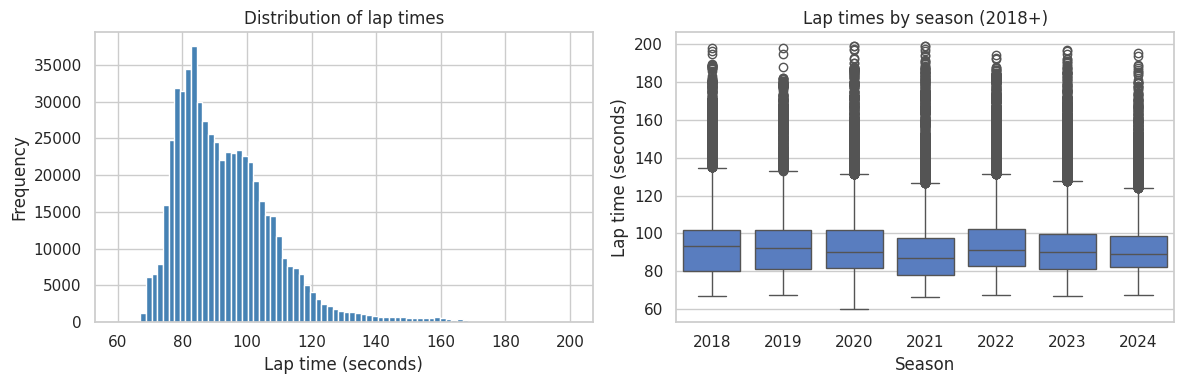

count    160845.000
mean         92.476
std          16.513
min          60.011
25%          81.340
50%          90.032
75%         100.346
max         199.316
Name: lap_time_s, dtype: float64


In [6]:
laps_eda = lap_times_data.copy()
laps_eda['lap_time_s'] = laps_eda['milliseconds'] / 1000.0
laps_eda = laps_eda.dropna(subset=['lap_time_s'])
laps_eda = laps_eda[(laps_eda['lap_time_s'] > 60) & (laps_eda['lap_time_s'] < 200)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(laps_eda['lap_time_s'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Lap time (seconds)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of lap times')

recent = laps_eda.merge(races_data[['raceId', 'year']], on='raceId', how='left')
recent = recent[recent['year'] >= 2018]
sns.boxplot(data=recent, x='year', y='lap_time_s', ax=axes[1])
axes[1].set_title('Lap times by season (2018+)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Lap time (seconds)')
plt.tight_layout()
plt.show()

print(recent['lap_time_s'].describe().round(3))

Lap times are right-skewed with a tight central cluster near typical race pace and a long tail from safety-car periods, pit-out laps, and incidents. Filtering to 60–200 seconds removes obvious outliers while retaining genuine race laps. Seasonal boxplots show regulation and circuit effects: absolute lap times are not directly comparable across years, so downstream models should work with **within-race residuals** rather than raw seconds.

In [7]:
missing_summary = pd.DataFrame({
    'column': lap_times_data.columns,
    'missing_count': lap_times_data.isna().sum().values,
    'missing_pct': (lap_times_data.isna().mean() * 100).values,
}).sort_values('missing_pct', ascending=False)
display(missing_summary)

pit_missing = pd.DataFrame({
    'column': pit_stops_data.columns,
    'missing_count': pit_stops_data.isna().sum().values,
    'missing_pct': (pit_stops_data.isna().mean() * 100).values,
}).sort_values('missing_pct', ascending=False)
display(pit_missing)

pit_coverage = pit_stops_data.groupby('raceId').size().describe()
print('Pit stops per race (distribution):')
display(pit_coverage)

,column,missing_count,missing_pct
0,raceId,0,0.0
1,driverId,0,0.0
2,lap,0,0.0
3,position,0,0.0
4,time,0,0.0
5,milliseconds,0,0.0


,column,missing_count,missing_pct
0,raceId,0,0.0
1,driverId,0,0.0
2,stop,0,0.0
3,lap,0,0.0
4,time,0,0.0
5,duration,0,0.0
6,milliseconds,0,0.0


Pit stops per race (distribution):


count    285.000000
mean      39.898246
std       16.680305
min       17.000000
25%       25.000000
50%       38.000000
75%       49.000000
max      101.000000
dtype: float64

Missingness is low in core timing fields (`milliseconds` in lap times, `milliseconds` in pit stops). Pit-stop tables exist only from 2012 onward in Ergast, so early seasons lack in-race stop detail. Pit-stop counts per race are concentrated around one to three stops, matching modern two- or three-stop strategies. Rows with missing lap milliseconds should be dropped before residual and GARCH modeling.

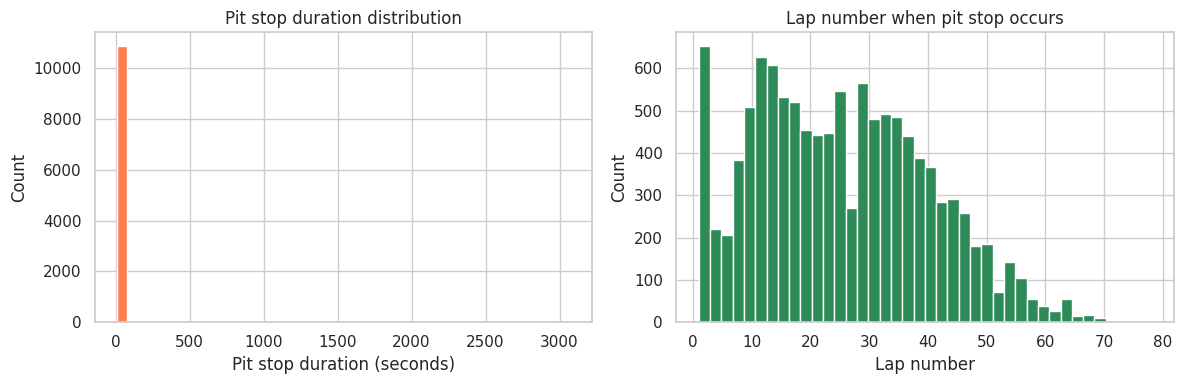

      count     mean      std
stop                         
1      5573   74.778  300.437
2      3716   81.414  270.539
3      1496   96.718  325.294
4       427  106.833  374.244
5       120  391.127  757.595
6        29  426.873  822.788
7         3   29.079    5.910
15        1   24.239      NaN
42        1   24.132      NaN
48        1   28.211      NaN
51        1   24.232      NaN
52        1   23.813      NaN
57        1   24.384      NaN
70        1   24.367      NaN


In [8]:
pits_eda = pit_stops_data.copy()
pits_eda['duration_s'] = pits_eda['milliseconds'] / 1000.0
pits_eda = pits_eda.dropna(subset=['duration_s', 'lap'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(pits_eda['duration_s'], bins=50, color='coral', edgecolor='white')
axes[0].set_xlabel('Pit stop duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Pit stop duration distribution')

axes[1].hist(pits_eda['lap'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_xlabel('Lap number')
axes[1].set_ylabel('Count')
axes[1].set_title('Lap number when pit stop occurs')
plt.tight_layout()
plt.show()

print(pits_eda.groupby('stop')['duration_s'].agg(['count', 'mean', 'std']).round(3))

Pit-stop durations cluster around 20–25 seconds for stationary service, with occasional longer stops for repairs. Stop lap numbers show preferred pit windows (often mid-race) rather than uniform spacing. First stops tend to be slightly faster on average than later stops when teams stack or change more components. These durations are direct **transaction costs** in the portfolio analogy: staying out saves pit time but increases tire risk.

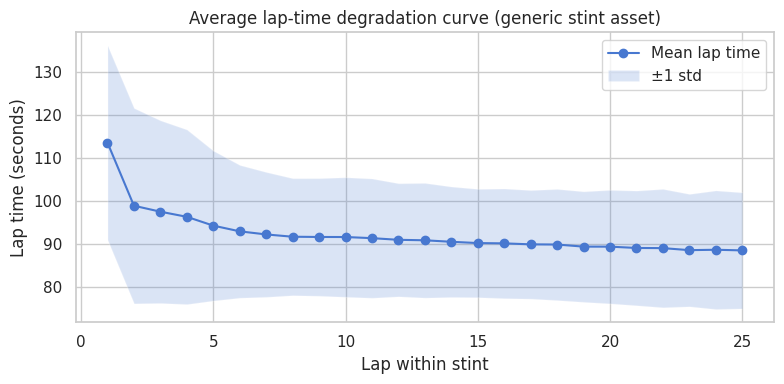

In [9]:
def assign_stints(laps_df, pits_df):
    laps = laps_df.merge(races_data[['raceId', 'year']], on='raceId', how='left')
    laps = laps.dropna(subset=['milliseconds'])
    laps['lap_time_s'] = laps['milliseconds'] / 1000.0
    laps = laps[(laps['lap_time_s'] > 60) & (laps['lap_time_s'] < 200)]

    pit_laps = pits_df.groupby(['raceId', 'driverId'])['lap'].apply(lambda x: sorted(x.tolist())).reset_index(name='pit_laps')
    laps = laps.merge(pit_laps, on=['raceId', 'driverId'], how='left')

    def stint_id(row):
        pit_laps = row['pit_laps'] if isinstance(row['pit_laps'], list) else []
        return sum(1 for p in pit_laps if row['lap'] > p)

    laps['stint_id'] = laps.apply(stint_id, axis=1)
    laps['stint_lap'] = laps.groupby(['raceId', 'driverId', 'stint_id']).cumcount() + 1
    return laps

stint_laps = assign_stints(lap_times_data, pit_stops_data)
stint_laps = stint_laps[stint_laps['year'] >= 2018]

stint_curve = stint_laps.groupby('stint_lap')['lap_time_s'].agg(['mean', 'std', 'count']).reset_index()
stint_curve = stint_curve[stint_curve['count'] >= 200].head(25)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stint_curve['stint_lap'], stint_curve['mean'], marker='o', label='Mean lap time')
ax.fill_between(
    stint_curve['stint_lap'],
    stint_curve['mean'] - stint_curve['std'],
    stint_curve['mean'] + stint_curve['std'],
    alpha=0.2,
    label='±1 std',
)
ax.set_xlabel('Lap within stint')
ax.set_ylabel('Lap time (seconds)')
ax.set_title('Average lap-time degradation curve (generic stint asset)')
ax.legend()
plt.tight_layout()
plt.show()

Treating each uninterrupted run between pits as a generic aging asset, lap times rise with stint length: early laps are fastest, then pace degrades as tires wear. The widening band (mean ± one standard deviation) shows that **uncertainty grows with stint age**, supporting time-varying volatility models rather than constant-variance assumptions. This curve is the empirical basis for expected return and risk inputs in the portfolio optimizer.

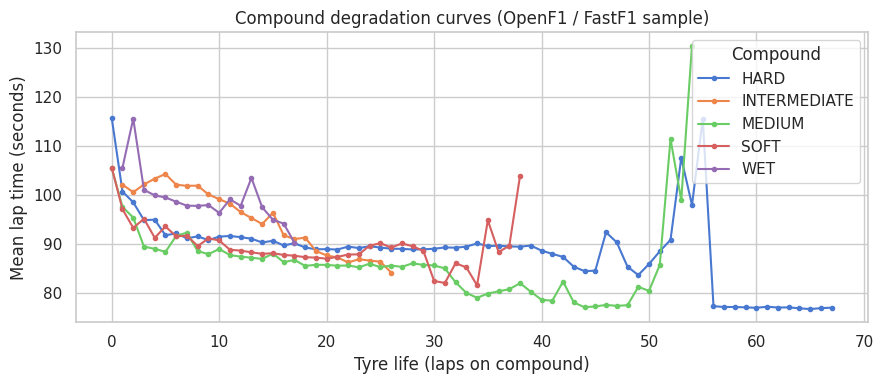

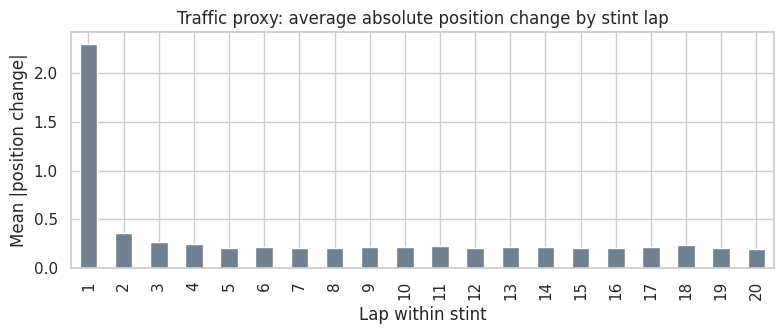

In [10]:
if not fastf1_laps_data.empty and 'Compound' in fastf1_laps_data.columns:
    ff = fastf1_laps_data.copy()
    if 'lap_time_s' not in ff.columns and 'LapTime' in ff.columns:
        ff['lap_time_s'] = ff['LapTime'].dt.total_seconds()
    ff = ff.dropna(subset=['lap_time_s', 'Compound', 'TyreLife'])
    ff = ff[(ff['lap_time_s'] > 60) & (ff['lap_time_s'] < 200)]

    compound_curve = ff.groupby(['Compound', 'TyreLife'])['lap_time_s'].mean().reset_index()
    compounds = compound_curve['Compound'].unique()

    fig, ax = plt.subplots(figsize=(9, 4))
    for compound in compounds:
        sub = compound_curve[compound_curve['Compound'] == compound]
        ax.plot(sub['TyreLife'], sub['lap_time_s'], marker='.', label=compound)
    ax.set_xlabel('Tyre life (laps on compound)')
    ax.set_ylabel('Mean lap time (seconds)')
    ax.set_title('Compound degradation curves (OpenF1 / FastF1 sample)')
    ax.legend(title='Compound')
    plt.tight_layout()
    plt.show()
else:
    print('Compound lap data not available; skipping compound-level EDA.')

stint_laps_sorted = stint_laps.sort_values(['raceId', 'driverId', 'lap'])
stint_laps_sorted['position_change'] = stint_laps_sorted.groupby(['raceId', 'driverId'])['position'].diff().abs()
traffic_risk = stint_laps_sorted.groupby('stint_lap')['position_change'].mean().head(20)

fig, ax = plt.subplots(figsize=(8, 3.5))
traffic_risk.plot(kind='bar', color='slategray', ax=ax)
ax.set_xlabel('Lap within stint')
ax.set_ylabel('Mean |position change|')
ax.set_title('Traffic proxy: average absolute position change by stint lap')
plt.tight_layout()
plt.show()

FastF1 separates compounds cleanly: softer tyres are faster when new but degrade more steeply; harder compounds trade peak pace for longevity. This justifies treating each compound as a distinct asset class in the covariance matrix. The traffic proxy (absolute lap-to-lap position change) rises through a stint, consistent with slower cars defending and faster cars attacking — a **downside risk** similar to drawdowns in finance, which the optimizer can penalize via higher variance weights.

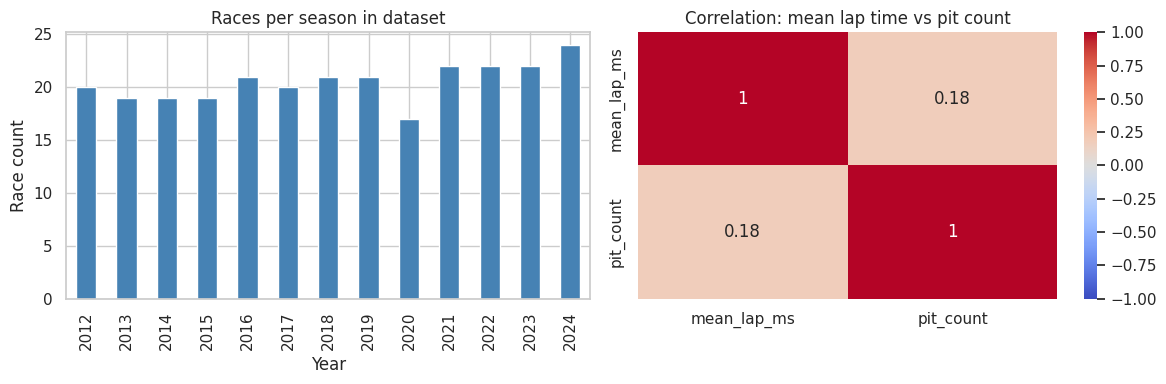

,mean_lap_ms,pit_count
year,,
2017,98024.11,34.70
2018,95406.69,25.52
2019,94634.20,30.95
2020,98267.34,34.94
2021,105323.87,36.27
2022,101483.66,36.59
2023,99528.79,41.45
2024,96338.88,34.38


In [11]:
race_summary = races_data.merge(
    lap_times_data.groupby('raceId')['milliseconds'].mean().rename('mean_lap_ms'),
    on='raceId',
    how='left',
)
race_summary = race_summary.merge(
    pit_stops_data.groupby('raceId').size().rename('pit_count'),
    on='raceId',
    how='left',
)
race_summary['pit_count'] = race_summary['pit_count'].fillna(0)
race_summary = race_summary[race_summary['year'] >= 2012]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
race_summary.groupby('year')['raceId'].count().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Races per season in dataset')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Race count')

sample_corr = race_summary[['mean_lap_ms', 'pit_count']].corr()
sns.heatmap(sample_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation: mean lap time vs pit count')
plt.tight_layout()
plt.show()

display(race_summary.groupby('year')[['mean_lap_ms', 'pit_count']].mean().tail(8).round(2))

Race coverage is complete for recent seasons, with pit-stop detail available from 2012 onward. The correlation between average lap time and total pit stops per race is weak at the aggregate level because circuit length and safety-car frequency dominate mean pace. Modeling therefore must be done at the **driver-stint-lap** granularity, not per race summary, before building covariance structures for portfolio optimization.

---

## Modeling pipeline

The cells below implement the strategy engine with a tighter structure: clean dry-race assets, a circuit-aware pace model, per-stint GARCH risk, and a constrained Markowitz / Black-Litterman allocator.

### Step 1: Asset definition and expected race time

We treat each **dry** tire compound as a portfolio asset (wet / intermediate are excluded from the dry-race allocator). The decision variable $x_c \in [0,1]$ is the fraction of race distance on compound $c$.

$$\sum_{c \in C_{\text{dry}}} x_c = 1, \quad x_c \geq 0$$

$$\mathbb{E}[T(\mathbf{x})] = N \sum_{c} x_c \cdot \mu_c + N_{\text{pits}}(\mathbf{x}) \cdot L_{\text{pit}}$$

where $N$ is a representative race length (median race distance in the sample), $L_{\text{pit}}$ is the historical pit-lane loss, and $N_{\text{pits}}$ is derived from how many stints the allocation implies given each compound's thermal limit $A_{\max}(c)$.


In [12]:
# Step 1: clean modeling frame + dry-race asset universe
# Priority: OpenF1/FastF1 compound data -> Kaggle Ergast fallback

COMPOUND_CYCLE = ['SOFT', 'MEDIUM', 'HARD']
WET_COMPOUNDS = {'WET', 'INTERMEDIATE', 'UNKNOWN'}

def build_kaggle_fallback_pipeline(laps_df, pits_df, drivers_df, year_min=YEAR_MIN, max_races=None):
    """Build modeling frame from Kaggle Ergast when compound APIs are unavailable."""
    laps = assign_stints(laps_df, pits_df)
    if 'year_x' in laps.columns:
        laps['year'] = laps['year_x']
        laps = laps.drop(columns=['year_x', 'year_y'], errors='ignore')
    elif 'year' not in laps.columns:
        laps = laps.merge(races_data[['raceId', 'year', 'circuitId']], on='raceId', how='left')
    if 'circuitId' not in laps.columns:
        laps = laps.merge(races_data[['raceId', 'circuitId']], on='raceId', how='left')
    laps = laps[laps['year'] >= year_min].copy()
    laps = laps.sort_values(['raceId', 'driverId', 'lap'])
    laps['Compound'] = laps['stint_id'].apply(lambda s: COMPOUND_CYCLE[int(s) % len(COMPOUND_CYCLE)])
    laps['TyreLife'] = laps['stint_lap']
    laps['LapNumber'] = laps['lap']
    laps['Position'] = laps['position']
    laps['traffic_density'] = laps.groupby(['raceId', 'driverId'])['position'].diff().abs().fillna(0)
    laps['TrackTemp'] = 30.0
    laps['AirTemp'] = 25.0
    laps['Season'] = laps['year']
    laps['GrandPrix'] = laps['circuitId'].astype(str)
    laps['race_key'] = laps['raceId'].astype(str)
    laps = laps.merge(drivers_df[['driverId', 'code']], on='driverId', how='left')
    laps['Driver'] = laps['code'].fillna(laps['driverId'].astype(str))
    if max_races is None:
        return laps
    recent_race_ids = (
        laps.groupby('raceId')['year'].first()
        .sort_values(ascending=False)
        .head(max_races)
        .index
    )
    return laps[laps['raceId'].isin(recent_race_ids)]


def clean_racing_laps(df, rel_cap=1.07):
    """Drop SC / pit-out / damaged outliers using within-race median pace."""
    out = df.copy()
    out = out[(out['lap_time_s'] > 60) & (out['lap_time_s'] < 200)]
    out['race_median'] = out.groupby('race_key')['lap_time_s'].transform('median')
    out = out[out['lap_time_s'] <= out['race_median'] * rel_cap]
    # Opening lap is often formation / chaos — keep for traffic features but exclude from pace fit later
    out['is_race_open'] = (out['LapNumber'] <= 1).astype(int)
    return out


has_compound_api = (
    not compound_laps_data.empty
    and 'Compound' in compound_laps_data.columns
    and 'TyreLife' in compound_laps_data.columns
    and COMPOUND_DATA_SOURCE != 'kaggle_fallback'
)

if has_compound_api:
    DATA_SOURCE = COMPOUND_DATA_SOURCE
    pipeline_df = compound_laps_data.copy()
    if 'Season' in pipeline_df.columns:
        pipeline_df = pipeline_df[
            (pipeline_df['Season'] >= OPENF1_YEAR_MIN) &
            (pipeline_df['Season'] <= YEAR_MAX)
        ].copy()
        print(f'Filtered to {OPENF1_YEAR_MIN}–{YEAR_MAX}: {len(pipeline_df):,} laps')
    if 'lap_time_s' not in pipeline_df.columns and 'LapTime' in pipeline_df.columns:
        pipeline_df['lap_time_s'] = pipeline_df['LapTime'].dt.total_seconds()
    pipeline_df['Compound'] = pipeline_df['Compound'].astype(str).str.upper()
    if 'session_key' in pipeline_df.columns:
        pipeline_df['race_key'] = pipeline_df['session_key'].astype(str)
    else:
        pipeline_df['race_key'] = (
            pipeline_df.get('Season', pd.Series(0, index=pipeline_df.index)).astype(str) + '_' +
            pipeline_df.get('GrandPrix', pd.Series('UNK', index=pipeline_df.index)).astype(str)
        )
    if 'GrandPrix' not in pipeline_df.columns:
        pipeline_df['GrandPrix'] = pipeline_df['race_key']
    if 'Season' not in pipeline_df.columns:
        pipeline_df['Season'] = YEAR_MIN
    sort_cols = [c for c in ['race_key', 'Driver', 'LapNumber'] if c in pipeline_df.columns]
    pipeline_df = pipeline_df.sort_values(sort_cols)
    if 'Position' in pipeline_df.columns:
        pipeline_df['traffic_density'] = (
            pipeline_df.groupby(['race_key', 'Driver'])['Position'].diff().abs().fillna(0)
        )
    else:
        pipeline_df['traffic_density'] = 0.0
    pipeline_df['TrackTemp'] = pd.to_numeric(pipeline_df.get('TrackTemp', 30.0), errors='coerce').fillna(30.0)
    pipeline_df['AirTemp'] = pd.to_numeric(pipeline_df.get('AirTemp', 25.0), errors='coerce').fillna(25.0)
    print(f'Data source: {DATA_SOURCE} (real compound labels)')
else:
    DATA_SOURCE = 'kaggle_fallback'
    pipeline_df = build_kaggle_fallback_pipeline(
        lap_times_data, pit_stops_data, drivers_data,
        year_min=YEAR_MIN,
        max_races=None,
    )
    print('Data source: Kaggle Ergast fallback (synthetic SOFT/MEDIUM/HARD from stint order)')

pipeline_df = clean_racing_laps(pipeline_df)
pipeline_df['TyreLife'] = pd.to_numeric(pipeline_df['TyreLife'], errors='coerce').fillna(1).clip(lower=1)
pipeline_df['LapNumber'] = pd.to_numeric(pipeline_df['LapNumber'], errors='coerce').fillna(1)
pipeline_df['Driver'] = pipeline_df['Driver'].astype(str)
pipeline_df['GrandPrix'] = pipeline_df['GrandPrix'].astype(str)
pipeline_df['Compound'] = pipeline_df['Compound'].astype(str).str.upper()
pipeline_df['tyre_life_sq'] = pipeline_df['TyreLife'] ** 2
pipeline_df['is_fresh'] = (pipeline_df['TyreLife'] <= 2).astype(int)

# Full compound list for diagnostics; dry subset for strategy optimization
ALL_COMPOUNDS = sorted(pipeline_df['Compound'].dropna().unique())
DRY_COMPOUNDS = [c for c in ['SOFT', 'MEDIUM', 'HARD'] if c in set(ALL_COMPOUNDS)]
if len(DRY_COMPOUNDS) < 2:
    DRY_COMPOUNDS = [c for c in ALL_COMPOUNDS if c not in WET_COMPOUNDS]
COMPOUNDS = DRY_COMPOUNDS  # strategy asset universe (dry race)
print('All compounds in data:', ALL_COMPOUNDS)
print('Strategy asset universe C_dry:', COMPOUNDS)

# Dry-lap frame used for pace/risk/optimization inputs
dry_df = pipeline_df[pipeline_df['Compound'].isin(COMPOUNDS)].copy()
print(f'Dry racing laps for modeling: {len(dry_df):,} / {len(pipeline_df):,}')

# Representative race length N: median of per-race max lap (not global max)
race_lengths = dry_df.groupby('race_key')['LapNumber'].max()
N_LAPS = int(np.clip(race_lengths.median(), 40, 80))
L_PIT = float(pit_stops_data['milliseconds'].dropna().median() / 1000.0)
# Stationary service is ~2–3 s; pit-lane loss is larger — use a race-strategy loss proxy
# Historical `milliseconds` mixes both; clamp to a realistic total pit loss band
L_PIT = float(np.clip(L_PIT, 18.0, 28.0))
print(f'Representative race laps N = {N_LAPS} (median observed={race_lengths.median():.0f})')
print(f'Pit-lane penalty L_pit = {L_PIT:.2f} s')

# Maximum stint life A_max(c): 90th percentile tyre life on dry compounds
A_MAX = dry_df.groupby('Compound')['TyreLife'].quantile(0.90).to_dict()
# Ensure feasibility: two compounds must be able to cover the race under FIA rule
for c in COMPOUNDS:
    A_MAX[c] = float(max(A_MAX.get(c, 20.0), np.ceil(N_LAPS / 3)))
display(pd.DataFrame({'compound': COMPOUNDS, 'A_max_laps': [A_MAX[c] for c in COMPOUNDS]}).round(1))

# Historical mean lap time prior (dry only)
mu_0 = dry_df.groupby('Compound')['lap_time_s'].mean().reindex(COMPOUNDS)
display(mu_0.round(3).rename('mu_0_raw_mean'))


Filtered to 2023–2025: 15,909 laps
Data source: openf1 (real compound labels)
All compounds in data: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT']
Strategy asset universe C_dry: ['SOFT', 'MEDIUM', 'HARD']
Dry racing laps for modeling: 14,046 / 14,053
Representative race laps N = 57 (median observed=57)
Pit-lane penalty L_pit = 23.61 s


,compound,A_max_laps
0,SOFT,23.0
1,MEDIUM,26.0
2,HARD,36.0


Compound
SOFT      88.561
MEDIUM    86.617
HARD      89.276
Name: mu_0_raw_mean, dtype: float64

### Step 2: LightGBM pace model and residual extraction

Predict **within-race relative pace** so circuit length does not dominate the loss. Categorical circuit / driver effects plus tyre age give the Markowitz mean vector $\mu$. Residuals $e_i$ feed GARCH.

$$r_i = t_i - \tilde{t}_{\text{race}}, \qquad e_i = r_i - \hat{r}_i(c, a_i, \mathbf{z}_i)$$

Train / test split is **temporal by race** (earlier races train, later races test) to avoid leakage.


In [13]:
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Relative pace target: removes circuit-length scale from the learning problem
model_df = dry_df[dry_df['is_race_open'] == 0].copy()
model_df['race_median'] = model_df.groupby('race_key')['lap_time_s'].transform('median')
model_df['rel_pace'] = model_df['lap_time_s'] - model_df['race_median']

PACE_FEATURES_CAT = ['Compound', 'Driver', 'GrandPrix']
PACE_FEATURES_NUM = [
    'TyreLife', 'tyre_life_sq', 'is_fresh',
    'TrackTemp', 'AirTemp', 'traffic_density', 'LapNumber', 'Season',
]
PACE_FEATURES_CAT = [c for c in PACE_FEATURES_CAT if c in model_df.columns]
PACE_FEATURES_NUM = [c for c in PACE_FEATURES_NUM if c in model_df.columns]

X_pace = model_df[PACE_FEATURES_CAT + PACE_FEATURES_NUM].copy()
y_pace = model_df['rel_pace'].values

# Temporal race holdout: last 20% of races by Season order
race_order = (
    model_df.groupby('race_key')['Season'].min()
    .sort_values(kind='mergesort')
    .index.tolist()
)
n_test_races = max(1, int(0.20 * len(race_order)))
test_races = set(race_order[-n_test_races:])
train_mask = ~model_df['race_key'].isin(test_races)
test_mask = model_df['race_key'].isin(test_races)

X_train_p = X_pace.loc[train_mask]
X_test_p = X_pace.loc[test_mask]
y_train_p = y_pace[train_mask.to_numpy()]
y_test_p = y_pace[test_mask.to_numpy()]
print(
    f'Temporal split: {int(train_mask.sum()):,} train / {int(test_mask.sum()):,} test laps '
    f'({len(race_order) - n_test_races} / {n_test_races} races)'
)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), PACE_FEATURES_CAT),
    ('num', 'passthrough', PACE_FEATURES_NUM),
])

pace_model = Pipeline([
    ('prep', preprocessor),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=63,
        max_depth=8,
        min_child_samples=40,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1,
    )),
])

pace_model.fit(X_train_p, y_train_p)

model_df['rel_hat'] = pace_model.predict(X_pace)
model_df['t_hat'] = model_df['race_median'] + model_df['rel_hat']
model_df['e_i'] = model_df['rel_pace'] - model_df['rel_hat']

# Attach predictions back without duplicate-column pileup on re-runs
pred_cols = ['t_hat', 'e_i', 'rel_pace', 'rel_hat', 'race_median']
for c in pred_cols:
    if c in dry_df.columns:
        dry_df = dry_df.drop(columns=[c])
    if c in pipeline_df.columns:
        pipeline_df = pipeline_df.drop(columns=[c])

keys = ['race_key', 'Driver', 'LapNumber']
dry_df = dry_df.merge(model_df[keys + pred_cols], on=keys, how='left')
pipeline_df = pipeline_df.merge(dry_df[keys + ['t_hat', 'e_i']], on=keys, how='left')

y_pred_test = pace_model.predict(X_test_p)
abs_actual = model_df.loc[test_mask, 'lap_time_s'].to_numpy()
abs_pred = model_df.loc[test_mask, 'race_median'].to_numpy() + y_pred_test

print('Relative pace — test MAE:', round(mean_absolute_error(y_test_p, y_pred_test), 4), 's')
print('Relative pace — test RMSE:', round(np.sqrt(mean_squared_error(y_test_p, y_pred_test)), 4), 's')
print('Relative pace — test R2:', round(r2_score(y_test_p, y_pred_test), 4))
print('Absolute lap  — test MAE:', round(mean_absolute_error(abs_actual, abs_pred), 4), 's')
print('Absolute lap  — test R2:', round(r2_score(abs_actual, abs_pred), 4))


def reference_mu(compounds, life_frac=0.45):
    """Model-implied expected absolute lap time at mid-stint reference conditions."""
    ref_gp = model_df['GrandPrix'].value_counts().index[0]
    ref_driver = model_df['Driver'].value_counts().index[0]
    ref_temp_track = float(model_df['TrackTemp'].median())
    ref_temp_air = float(model_df['AirTemp'].median())
    ref_season = int(model_df['Season'].median())
    ref_race_med = float(model_df['race_median'].median())
    rows = []
    for c in compounds:
        life = max(1.0, life_frac * A_MAX[c])
        rows.append({
            'Compound': c,
            'Driver': ref_driver,
            'GrandPrix': ref_gp,
            'TyreLife': life,
            'tyre_life_sq': life ** 2,
            'is_fresh': int(life <= 2),
            'TrackTemp': ref_temp_track,
            'AirTemp': ref_temp_air,
            'traffic_density': 0.0,
            'LapNumber': int(N_LAPS * 0.4),
            'Season': ref_season,
        })
    ref_X = pd.DataFrame(rows)[PACE_FEATURES_CAT + PACE_FEATURES_NUM]
    return ref_race_med + pace_model.predict(ref_X)


mu_vec = reference_mu(COMPOUNDS)
mu_table = pd.DataFrame({
    'compound': COMPOUNDS,
    'mu_model_midstint': mu_vec,
    'mu_0_raw_mean': mu_0.reindex(COMPOUNDS).values,
})
display(mu_table.round(3))
display(model_df[['Compound', 'TyreLife', 'lap_time_s', 't_hat', 'e_i']].head())


Temporal split: 11,812 train / 2,174 test laps (12 / 2 races)
Relative pace — test MAE: 0.6556 s
Relative pace — test RMSE: 0.9286 s
Relative pace — test R2: 0.4444
Absolute lap  — test MAE: 0.6556 s
Absolute lap  — test R2: 0.9886


,compound,mu_model_midstint,mu_0_raw_mean
0,SOFT,85.419,88.561
1,MEDIUM,85.915,86.617
2,HARD,85.818,89.276


,Compound,TyreLife,lap_time_s,t_hat,e_i
1090,MEDIUM,1,98.916,97.715778,1.200222
1110,MEDIUM,2,97.065,96.788605,0.276395
1130,MEDIUM,3,96.913,96.914244,-0.001244
1150,MEDIUM,4,97.108,96.684776,0.423224
1170,MEDIUM,5,97.004,96.633946,0.370054


### Step 3: GARCH(1,1) dynamic risk and covariance matrix

GARCH is fit on **per-driver, per-race residual sequences** (not one glued global series). That keeps the time-series local and is why earlier global fits silently failed.

$$e_{i} = \sigma_i \epsilon_i, \quad \sigma_i^2 = \omega + \alpha e_{i-1}^2 + \beta \sigma_{i-1}^2$$

Compound variance $\Sigma_{cc}$ is the mean terminal conditional variance across successful stint fits. Off-diagonals use shrunk residual correlations.


,compound,n_series_fit,n_series_tried,omega_mean,alpha_mean,beta_mean,alpha+beta,sigma2_garch,sigma2_sample
0,SOFT,19,37,0.5089,0.4430,0.1890,0.6320,1.3871,0.8373
1,MEDIUM,58,96,0.3839,0.2352,0.3997,0.6349,0.4684,0.5064
2,HARD,89,150,0.4829,0.2210,0.4540,0.6749,0.3305,0.3805


GARCH landed for 3/3 dry compounds (166 stint series fitted)


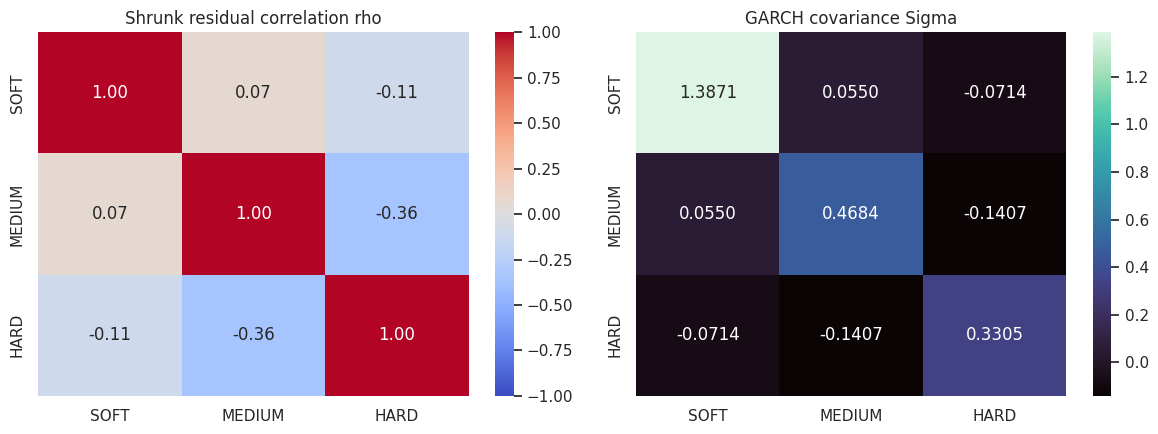

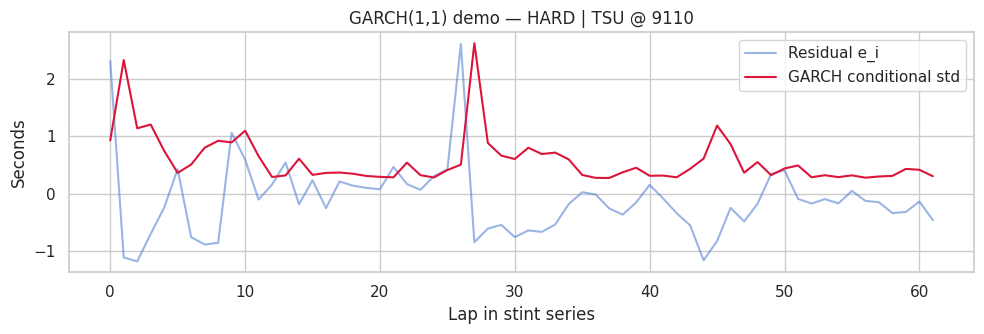

In [14]:
from arch import arch_model

MIN_GARCH_LEN = 25
garch_var_by_compound = {}
garch_params = []
garch_fit_counts = []

resid_df = dry_df.dropna(subset=['e_i']).copy()
resid_df = resid_df.sort_values(['race_key', 'Driver', 'LapNumber'])

for compound in COMPOUNDS:
    sub = resid_df[resid_df['Compound'] == compound]
    terminal_vars = []
    alphas, betas, omegas = [], [], []
    n_attempted, n_ok = 0, 0

    for _, g in sub.groupby(['race_key', 'Driver']):
        r = g['e_i'].astype(float).values
        if len(r) < MIN_GARCH_LEN:
            continue
        n_attempted += 1
        # Scale residuals into a numerically friendly range; arch rescale=True tracks the factor
        try:
            am = arch_model(r, mean='Zero', vol='Garch', p=1, q=1, dist='normal', rescale=True)
            fit = am.fit(disp='off', show_warning=False, options={'maxiter': 400})
            # conditional_volatility is already in original residual units when using rescale
            cond = np.asarray(fit.conditional_volatility, dtype=float)
            if not np.isfinite(cond).all() or cond[-1] <= 0:
                continue
            terminal_vars.append(float(cond[-1] ** 2))
            a = float(fit.params.get('alpha[1]', np.nan))
            b = float(fit.params.get('beta[1]', np.nan))
            w = float(fit.params.get('omega', np.nan))
            if np.isfinite(a) and np.isfinite(b) and (a + b) < 0.999:
                alphas.append(a)
                betas.append(b)
                omegas.append(w)
                n_ok += 1
        except Exception:
            continue

    sample_var = float(sub['e_i'].var()) if len(sub) > 1 else 1e-4
    if terminal_vars:
        garch_var_by_compound[compound] = float(np.median(terminal_vars))
        garch_params.append({
            'compound': compound,
            'n_series_fit': n_ok,
            'n_series_tried': n_attempted,
            'omega_mean': float(np.mean(omegas)) if omegas else np.nan,
            'alpha_mean': float(np.mean(alphas)) if alphas else np.nan,
            'beta_mean': float(np.mean(betas)) if betas else np.nan,
            'alpha+beta': float(np.mean(alphas) + np.mean(betas)) if alphas and betas else np.nan,
            'sigma2_garch': garch_var_by_compound[compound],
            'sigma2_sample': sample_var,
        })
    else:
        garch_var_by_compound[compound] = sample_var
        garch_params.append({
            'compound': compound,
            'n_series_fit': 0,
            'n_series_tried': n_attempted,
            'omega_mean': np.nan,
            'alpha_mean': np.nan,
            'beta_mean': np.nan,
            'alpha+beta': np.nan,
            'sigma2_garch': sample_var,
            'sigma2_sample': sample_var,
        })
    garch_fit_counts.append({'compound': compound, 'fits': n_ok, 'tried': n_attempted})

garch_params_df = pd.DataFrame(garch_params).round(4)
display(garch_params_df)
n_landed = int((garch_params_df['n_series_fit'] > 0).sum())
print(f'GARCH landed for {n_landed}/{len(COMPOUNDS)} dry compounds '
      f'({int(garch_params_df["n_series_fit"].sum())} stint series fitted)')

# Correlation from race-level mean residual by compound, shrunk toward identity
race_comp = resid_df.pivot_table(index='race_key', columns='Compound', values='e_i', aggfunc='mean')
race_comp = race_comp.reindex(columns=COMPOUNDS)
rho_raw = race_comp.corr().fillna(0.0).values
np.fill_diagonal(rho_raw, 1.0)
shrink = 0.35
rho_mat = (1 - shrink) * rho_raw + shrink * np.eye(len(COMPOUNDS))

sigma_vec = np.array([np.sqrt(max(garch_var_by_compound[c], 1e-6)) for c in COMPOUNDS])
Sigma = np.outer(sigma_vec, sigma_vec) * rho_mat
eigvals, eigvecs = np.linalg.eigh(Sigma)
eigvals = np.clip(eigvals, 1e-8, None)
Sigma = eigvecs @ np.diag(eigvals) @ eigvecs.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(rho_mat, xticklabels=COMPOUNDS, yticklabels=COMPOUNDS, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Shrunk residual correlation rho')
sns.heatmap(Sigma, xticklabels=COMPOUNDS, yticklabels=COMPOUNDS, annot=True, fmt='.4f',
            cmap='mako', ax=axes[1])
axes[1].set_title('GARCH covariance Sigma')
plt.tight_layout()
plt.show()

# Demo path: longest Soft (or top compound) driver-race residual series
top_compound = resid_df['Compound'].value_counts().idxmax()
demo = (
    resid_df[resid_df['Compound'] == top_compound]
    .groupby(['race_key', 'Driver'])
    .filter(lambda g: len(g) >= MIN_GARCH_LEN)
)
if not demo.empty:
    key = demo.groupby(['race_key', 'Driver']).size().idxmax()
    demo_r = demo[(demo['race_key'] == key[0]) & (demo['Driver'] == key[1])]['e_i'].values
    gdemo = arch_model(demo_r, mean='Zero', vol='Garch', p=1, q=1, rescale=True).fit(disp='off', show_warning=False)
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(demo_r, alpha=0.55, label='Residual e_i')
    ax.plot(gdemo.conditional_volatility, color='crimson', label='GARCH conditional std')
    ax.set_title(f'GARCH(1,1) demo — {top_compound} | {key[1]} @ {key[0]}')
    ax.set_xlabel('Lap in stint series')
    ax.set_ylabel('Seconds')
    ax.legend()
    plt.tight_layout()
    plt.show()


### Step 4: Markowitz mean-variance strategy engine

Dry-race allocator over Soft / Medium / Hard only. We **enumerate FIA-legal 2- and 3-compound supports**, then run SLSQP on each subset. That avoids the old failure mode of spreading weight onto Wet / Intermediate.

$$\min_{\mathbf{x}} \left( \boldsymbol{\mu}^\top \mathbf{x} + \lambda \, \mathbf{x}^\top \boldsymbol{\Sigma} \mathbf{x} + \frac{N_{\text{pits}}(\mathbf{x})}{N} L_{\text{pit}} \right)$$

$$N_{\text{stints}}(\mathbf{x}) = \sum_c \left\lceil \frac{x_c N}{A_{\max}(c)} \right\rceil, \quad N_{\text{pits}} = \max\!\left(0,\, N_{\text{stints}} - 1\right)$$

Subject to $\sum x_c = 1$, $x_c \ge x_{\min}$ on the active support, $x_c \le A_{\max}(c)/N$, and support size $\in \{2,3\}$.


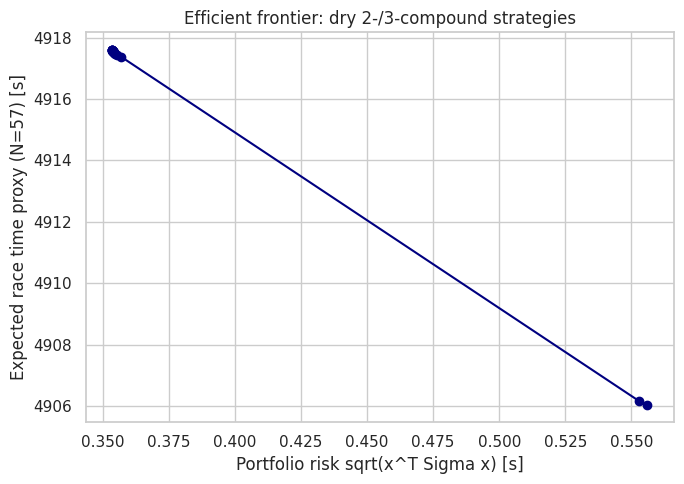

Optimizer success=True  support=['MEDIUM', 'HARD']  active=2  stints=2  pits=1  lambda=1.5


,compound,weight,laps_allocated,A_max,mu_s
2,HARD,0.5936,33.8,36.0,85.8180
1,MEDIUM,0.4064,23.2,26.0,85.9147


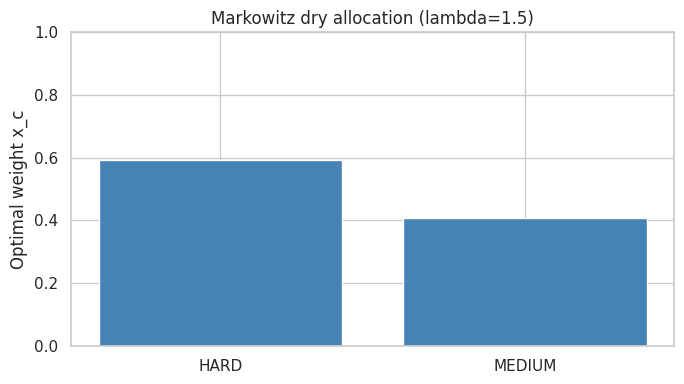

In [15]:
from itertools import combinations
from scipy.optimize import minimize

n_assets = len(COMPOUNDS)
a_max_vec = np.array([A_MAX[c] / float(N_LAPS) for c in COMPOUNDS], dtype=float)
MIN_COMPOUND_WEIGHT = 0.15
DEFAULT_LAMBDA = 1.5
RISK_SCALE = 1.0


def count_active_compounds(x, threshold=MIN_COMPOUND_WEIGHT):
    return int(np.sum(np.asarray(x) >= threshold))


def implied_stints(x):
    x = np.asarray(x, dtype=float)
    stints = 0
    for i, xi in enumerate(x):
        if xi <= 1e-8:
            continue
        laps_c = xi * N_LAPS
        stints += int(np.ceil(laps_c / max(A_MAX[COMPOUNDS[i]], 1.0)))
    return max(stints, count_active_compounds(x))


def pit_stop_count(x):
    return max(0, implied_stints(x) - 1)


def race_time_objective(x, mu, sigma, lam, l_pit):
    x = np.asarray(x, dtype=float)
    lap_cost = float(mu @ x)
    risk_cost = float(lam * RISK_SCALE * (x @ sigma @ x))
    pit_cost = pit_stop_count(x) * l_pit / N_LAPS
    return lap_cost + risk_cost + pit_cost


def _optimize_support(mu, sigma, support, lam, l_pit):
    """Optimize weights on a fixed compound subset (others fixed at 0)."""
    support = list(support)
    k = len(support)
    mu_s = mu[support]
    sigma_s = sigma[np.ix_(support, support)]
    a_max_s = a_max_vec[support]

    if k == 1:
        x_full = np.zeros(n_assets)
        x_full[support[0]] = 1.0
        # Illegal under dry FIA rule — skip by huge penalty
        return None, np.inf

    x0 = np.minimum(np.ones(k) / k, a_max_s)
    x0 = x0 / x0.sum()
    bounds = [(MIN_COMPOUND_WEIGHT, float(min(1.0, a_max_s[i]))) for i in range(k)]
    # Feasibility: sum of upper bounds must be >= 1 and sum of mins <= 1
    if sum(b[1] for b in bounds) < 1.0 - 1e-8 or sum(b[0] for b in bounds) > 1.0 + 1e-8:
        return None, np.inf

    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0}]

    def obj(xs):
        x_full = np.zeros(n_assets)
        x_full[support] = xs
        return race_time_objective(x_full, mu, sigma, lam, l_pit)

    res = minimize(
        obj, x0, method='SLSQP', bounds=bounds, constraints=constraints,
        options={'maxiter': 500, 'ftol': 1e-10, 'disp': False},
    )
    if not res.success:
        return None, np.inf
    xs = np.clip(res.x, 0, None)
    xs = xs / xs.sum()
    x_full = np.zeros(n_assets)
    x_full[support] = xs
    return x_full, float(obj(xs))


def optimize_strategy(mu, sigma, lam=DEFAULT_LAMBDA, l_pit=L_PIT):
    """Enumerate FIA-legal 2- and 3-compound supports, then SLSQP on each."""
    mu = np.asarray(mu, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    best_x, best_val, best_support = None, np.inf, None

    for k in (2, 3):
        if n_assets < k:
            continue
        for support in combinations(range(n_assets), k):
            # Thermal coverage check: selected compounds must cover N laps
            if sum(A_MAX[COMPOUNDS[i]] for i in support) < N_LAPS * 0.95:
                continue
            x, val = _optimize_support(mu, sigma, support, lam, l_pit)
            if x is not None and val < best_val:
                best_x, best_val, best_support = x, val, support

    class Result:
        pass
    out = Result()
    if best_x is None:
        # Fallback equal split on two fastest compounds
        order = np.argsort(mu)
        x = np.zeros(n_assets)
        x[order[0]] = 0.55
        x[order[1]] = 0.45
        out.x = x
        out.success = False
        out.fun = race_time_objective(x, mu, sigma, lam, l_pit)
        out.support = tuple(order[:2])
    else:
        out.x = best_x
        out.success = True
        out.fun = best_val
        out.support = best_support
    return out


# Efficient frontier over lambda
lambda_grid = np.linspace(0.25, 6.0, 18)
frontier_time, frontier_risk, frontier_allocations, frontier_lams = [], [], [], []
for lam in lambda_grid:
    res = optimize_strategy(mu_vec, Sigma, lam=lam)
    x_star = res.x
    frontier_lams.append(lam)
    frontier_time.append(float(mu_vec @ x_star) * N_LAPS + pit_stop_count(x_star) * L_PIT)
    frontier_risk.append(float(np.sqrt(max(x_star @ Sigma @ x_star, 0.0))))
    frontier_allocations.append(x_star)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(frontier_risk, frontier_time, marker='o', color='navy')
ax.set_xlabel('Portfolio risk sqrt(x^T Sigma x) [s]')
ax.set_ylabel(f'Expected race time proxy (N={N_LAPS}) [s]')
ax.set_title('Efficient frontier: dry 2-/3-compound strategies')
plt.tight_layout()
plt.show()

opt_result = optimize_strategy(mu_vec, Sigma, lam=DEFAULT_LAMBDA)
x_optimal = opt_result.x
allocation_df = pd.DataFrame({
    'compound': COMPOUNDS,
    'weight': x_optimal,
    'laps_allocated': np.round(x_optimal * N_LAPS, 1),
    'A_max': [A_MAX[c] for c in COMPOUNDS],
    'mu_s': mu_vec,
})
allocation_df = allocation_df[allocation_df['weight'] > 0.005].sort_values('weight', ascending=False)
used = [COMPOUNDS[i] for i in opt_result.support]
print(
    f'Optimizer success={opt_result.success}  support={used}  '
    f'active={count_active_compounds(x_optimal)}  '
    f'stints={implied_stints(x_optimal)}  pits={pit_stop_count(x_optimal)}  '
    f'lambda={DEFAULT_LAMBDA}'
)
display(allocation_df.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(allocation_df['compound'], allocation_df['weight'], color='steelblue')
ax.set_ylabel('Optimal weight x_c')
ax.set_title(f'Markowitz dry allocation (lambda={DEFAULT_LAMBDA})')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### Step 5: Black-Litterman pit-wall views

Blend the model prior $\boldsymbol{\mu}$ with a pit-wall view. View uncertainty $\Omega$ is calibrated so a confident 0.4 s/lap Medium graining call actually shifts weights.

$$\boldsymbol{\mu}^* = \left[(\tau\boldsymbol{\Sigma})^{-1} + \mathbf{P}^\top\boldsymbol{\Omega}^{-1}\mathbf{P}\right]^{-1}
\left[(\tau\boldsymbol{\Sigma})^{-1}\boldsymbol{\mu} + \mathbf{P}^\top\boldsymbol{\Omega}^{-1}\mathbf{Q}\right]$$


,compound,mu_prior,mu_star_BL,delta
0,SOFT,85.4186,85.4374,0.0188
1,MEDIUM,85.9147,86.0747,0.1600
2,HARD,85.8180,85.7700,-0.0481


,compound,weight_markowitz,weight_black_litterman,shift
0,SOFT,0.0000,0.0000,0.000
1,MEDIUM,0.4064,0.3684,-0.038
2,HARD,0.5936,0.6316,0.038


BL pits=1  Medium shift=-0.0380


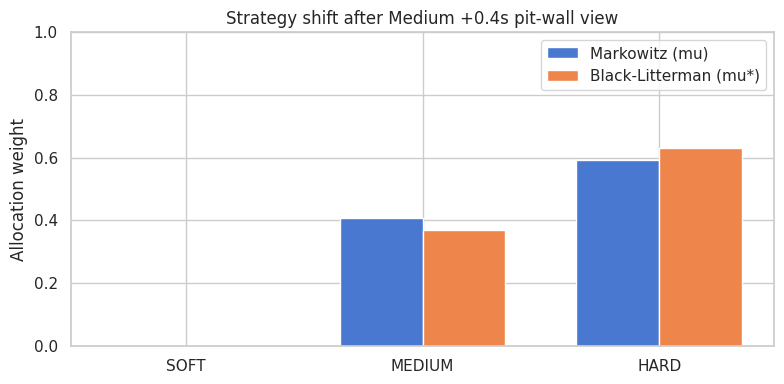

In [16]:
def black_litterman(mu_prior, sigma, P, Q, omega, tau=0.05):
    sigma = np.asarray(sigma, dtype=float)
    mu_prior = np.asarray(mu_prior, dtype=float).reshape(-1, 1)
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float).reshape(-1, 1)
    omega = np.asarray(omega, dtype=float)
    # Numerical guard: keep Sigma well-conditioned
    sigma = sigma + 1e-6 * np.eye(sigma.shape[0])
    tau_sigma_inv = np.linalg.inv(tau * sigma)
    omega_inv = np.linalg.inv(omega)
    middle = np.linalg.inv(tau_sigma_inv + P.T @ omega_inv @ P)
    rhs = tau_sigma_inv @ mu_prior + P.T @ omega_inv @ Q
    return (middle @ rhs).flatten()

mu_prior = np.asarray(mu_vec, dtype=float).copy()
tau_bl = 0.10

# Pit-wall view: Medium is 0.4 s/lap slower than prior due to graining
if 'MEDIUM' in COMPOUNDS:
    med_idx = COMPOUNDS.index('MEDIUM')
else:
    med_idx = int(np.argmax(mu_prior))

P_view = np.zeros((1, n_assets))
P_view[0, med_idx] = 1.0
Q_view = np.array([mu_prior[med_idx] + 0.4])
# Confident view: Omega small vs tau*Sigma so posterior moves ~toward Q
Omega_view = np.array([[max(1e-4, 0.15 * float(Sigma[med_idx, med_idx]))]])

mu_star = black_litterman(mu_prior, Sigma, P_view, Q_view, Omega_view, tau=tau_bl)

bl_compare = pd.DataFrame({
    'compound': COMPOUNDS,
    'mu_prior': mu_prior,
    'mu_star_BL': mu_star,
    'delta': mu_star - mu_prior,
}).round(4)
display(bl_compare)

bl_result = optimize_strategy(mu_star, Sigma, lam=DEFAULT_LAMBDA)
x_bl = bl_result.x if bl_result.success else x_optimal.copy()

comparison = pd.DataFrame({
    'compound': COMPOUNDS,
    'weight_markowitz': x_optimal,
    'weight_black_litterman': x_bl,
})
comparison['shift'] = comparison['weight_black_litterman'] - comparison['weight_markowitz']
display(comparison.round(4))
print(
    f'BL pits={pit_stop_count(x_bl)}  '
    f'Medium shift={comparison.loc[comparison.compound == COMPOUNDS[med_idx], "shift"].values[0]:+.4f}'
)

fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(COMPOUNDS))
width = 0.35
ax.bar(x_pos - width / 2, x_optimal, width, label='Markowitz (mu)')
ax.bar(x_pos + width / 2, x_bl, width, label='Black-Litterman (mu*)')
ax.set_xticks(x_pos)
ax.set_xticklabels(COMPOUNDS)
ax.set_ylabel('Allocation weight')
ax.set_title('Strategy shift after Medium +0.4s pit-wall view')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### Step 6: Model performance analysis

Diagnostics for the rebuilt stack: (1) temporal holdout pace accuracy, (2) GARCH fit coverage, (3) allocation sensitivity across $\lambda$, (4) residual health by compound.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

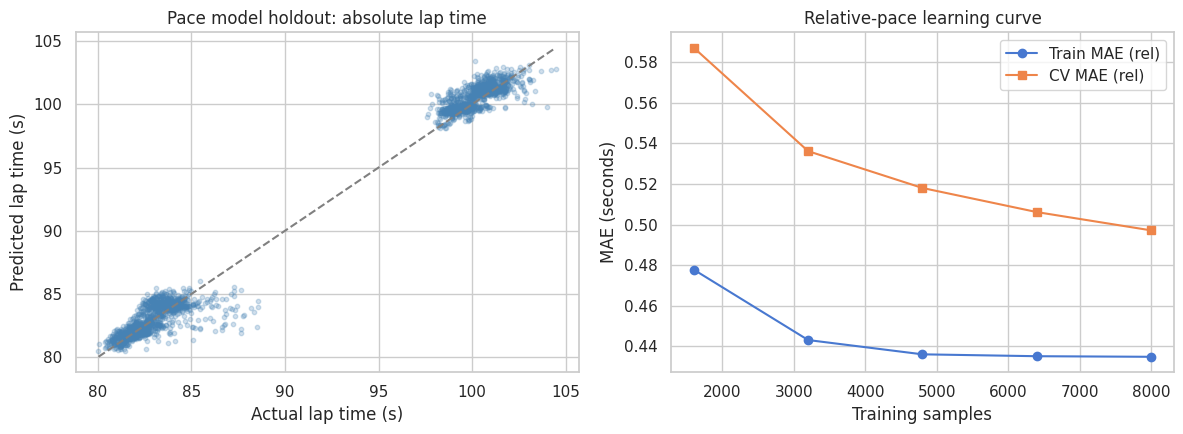

Holdout absolute MAE: 0.6556 s
Holdout absolute R2: 0.9886
Holdout relative MAE: 0.6556 s
Holdout relative R2: 0.4444


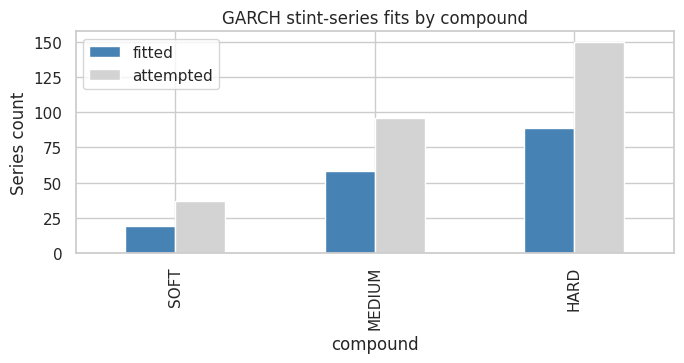

,compound,n_series_fit,alpha_mean,beta_mean,alpha+beta,sigma2_garch
0,SOFT,19,0.4430,0.1890,0.6320,1.3871
1,MEDIUM,58,0.2352,0.3997,0.6349,0.4684
2,HARD,89,0.2210,0.4540,0.6749,0.3305


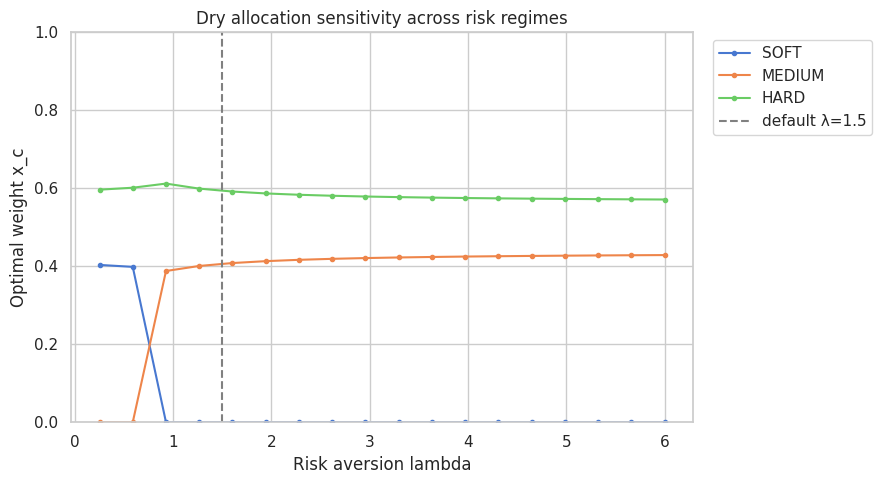

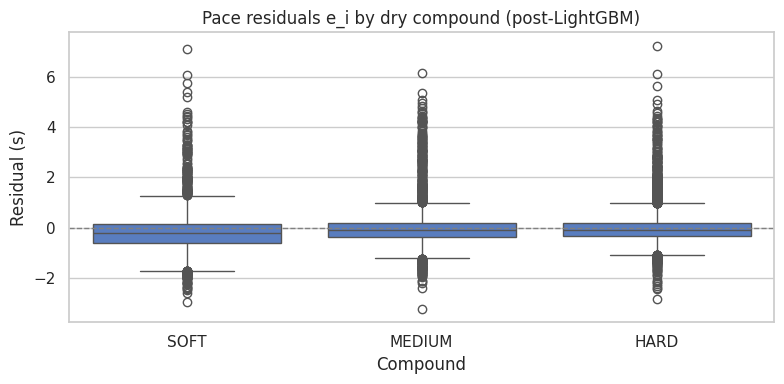

,metric,value
0,pace_abs_MAE_holdout_s,0.6556
1,pace_abs_R2_holdout,0.9886
2,pace_rel_R2_holdout,0.4444
3,garch_compounds_landed,3.0000
4,garch_stint_fits,166.0000
5,markowitz_active_compounds,2.0000
6,markowitz_pits,1.0000
7,bl_medium_weight_shift,-0.0380


In [17]:
from sklearn.model_selection import learning_curve

# --- 6a. Pace model: predicted vs actual (absolute) on temporal holdout ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(abs_actual, abs_pred, alpha=0.25, s=10, color='steelblue')
lims = [min(abs_actual.min(), abs_pred.min()), max(abs_actual.max(), abs_pred.max())]
axes[0].plot(lims, lims, '--', color='gray')
axes[0].set_xlabel('Actual lap time (s)')
axes[0].set_ylabel('Predicted lap time (s)')
axes[0].set_title('Pace model holdout: absolute lap time')

# Learning curve on a race-subsampled frame for speed
sample_frac = min(1.0, 12000 / max(len(X_pace), 1))
X_lc = X_pace.sample(frac=sample_frac, random_state=42) if sample_frac < 1 else X_pace
y_lc = model_df.loc[X_lc.index, 'rel_pace'].values
train_sizes, train_scores, val_scores = learning_curve(
    pace_model, X_lc, y_lc, cv=3, scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1,
)
axes[1].plot(train_sizes, -train_scores.mean(axis=1), marker='o', label='Train MAE (rel)')
axes[1].plot(train_sizes, -val_scores.mean(axis=1), marker='s', label='CV MAE (rel)')
axes[1].set_xlabel('Training samples')
axes[1].set_ylabel('MAE (seconds)')
axes[1].set_title('Relative-pace learning curve')
axes[1].legend()
plt.tight_layout()
plt.show()

print('Holdout absolute MAE:', round(mean_absolute_error(abs_actual, abs_pred), 4), 's')
print('Holdout absolute R2:', round(r2_score(abs_actual, abs_pred), 4))
print('Holdout relative MAE:', round(mean_absolute_error(y_test_p, y_pred_test), 4), 's')
print('Holdout relative R2:', round(r2_score(y_test_p, y_pred_test), 4))

# --- 6b. GARCH coverage summary ---
fig, ax = plt.subplots(figsize=(7, 3.8))
gplot = garch_params_df.set_index('compound')[['n_series_fit', 'n_series_tried']]
gplot.plot(kind='bar', ax=ax, color=['steelblue', 'lightgray'])
ax.set_title('GARCH stint-series fits by compound')
ax.set_ylabel('Series count')
ax.legend(['fitted', 'attempted'])
plt.tight_layout()
plt.show()
display(garch_params_df[['compound', 'n_series_fit', 'alpha_mean', 'beta_mean', 'alpha+beta', 'sigma2_garch']].round(4))

# --- 6c. Optimizer sensitivity across lambda ---
alloc_matrix = np.array(frontier_allocations)
fig, ax = plt.subplots(figsize=(9, 5))
for i, compound in enumerate(COMPOUNDS):
    ax.plot(frontier_lams, alloc_matrix[:, i], marker='.', label=compound)
ax.axvline(DEFAULT_LAMBDA, color='gray', ls='--', label=f'default λ={DEFAULT_LAMBDA}')
ax.set_xlabel('Risk aversion lambda')
ax.set_ylabel('Optimal weight x_c')
ax.set_title('Dry allocation sensitivity across risk regimes')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 6d. Residual distribution by compound ---
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=resid_df, x='Compound', y='e_i', order=COMPOUNDS, ax=ax)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title('Pace residuals e_i by dry compound (post-LightGBM)')
ax.set_ylabel('Residual (s)')
plt.tight_layout()
plt.show()

# --- 6e. Compact scorecard ---
scorecard = pd.DataFrame([
    {'metric': 'pace_abs_MAE_holdout_s', 'value': mean_absolute_error(abs_actual, abs_pred)},
    {'metric': 'pace_abs_R2_holdout', 'value': r2_score(abs_actual, abs_pred)},
    {'metric': 'pace_rel_R2_holdout', 'value': r2_score(y_test_p, y_pred_test)},
    {'metric': 'garch_compounds_landed', 'value': n_landed},
    {'metric': 'garch_stint_fits', 'value': int(garch_params_df['n_series_fit'].sum())},
    {'metric': 'markowitz_active_compounds', 'value': count_active_compounds(x_optimal)},
    {'metric': 'markowitz_pits', 'value': pit_stop_count(x_optimal)},
    {'metric': 'bl_medium_weight_shift', 'value': float(comparison.loc[comparison.compound == COMPOUNDS[med_idx], 'shift'].values[0])},
])
display(scorecard.round(4))


---

## Step 7: Strategy backtest (discrete plan search)

Continuous weights were collapsing to equal Soft/Medium/Hard thirds — the same as a dumb 2-stop heuristic — so Markowitz could not beat the baseline.

We now **enumerate realistic 1- and 2-stop stint plans**, score each with the pace-model race simulator, and pick:

- **mean_only** — lowest simulated race time  
- **markowitz** — lowest $\text{sim time} + \lambda \cdot \kappa \cdot \sigma(x)$ (risk-adjusted)  
- **black_litterman** — same as Markowitz after a Medium +0.4 s/lap pit-wall penalty  

The research target is concrete: find **tenths to a few seconds** vs actual strategies and vs the equal-thirds baseline on at least some holdout races.


In [18]:
# Step 7a: discrete candidate plans + pace-sim scoring

STINT_ORDER = [c for c in ['SOFT', 'MEDIUM', 'HARD'] if c in COMPOUNDS]
RISK_KAPPA = 8.0  # converts portfolio std (s) into seconds of objective penalty


def stints_to_weights(stints, compounds, n_laps):
    w = np.zeros(len(compounds), dtype=float)
    idx = {c: i for i, c in enumerate(compounds)}
    for c, L in stints:
        if c in idx:
            w[idx[c]] += L
    if n_laps > 0:
        w = w / float(n_laps)
    return w


def plan_key(stints):
    return tuple((c, int(L)) for c, L in stints)


def extract_driver_stints(df_driver):
    d = df_driver.sort_values('LapNumber')
    stints, cur_c, cur_n, prev_life = [], None, 0, None
    for _, row in d.iterrows():
        c = str(row['Compound']).upper()
        life = float(row.get('TyreLife', np.nan))
        new_stint = (
            cur_c is None
            or c != cur_c
            or (np.isfinite(life) and prev_life is not None and life + 0.5 < prev_life)
        )
        if new_stint and cur_c is not None and cur_n > 0:
            stints.append((cur_c, cur_n))
            cur_n = 0
        cur_c = c
        cur_n += 1
        prev_life = life if np.isfinite(life) else prev_life
    if cur_c is not None and cur_n > 0:
        stints.append((cur_c, cur_n))
    return stints


def generate_candidate_plans(n_laps, a_max, step=2):
    """Enumerate feasible 1-stop and 2-stop dry plans (FIA: >=2 compounds)."""
    plans = []
    caps = {c: int(max(1, np.floor(a_max.get(c, n_laps // 2)))) for c in COMPOUNDS}

    def add(stints):
        if len(stints) < 2:
            return
        if sum(L for _, L in stints) != n_laps:
            return
        if any(L < 1 or L > caps.get(c, n_laps) for c, L in stints):
            return
        plans.append([(c, int(L)) for c, L in stints])

    # --- 1-stop pairs ---
    pairs = [
        ('SOFT', 'HARD'), ('SOFT', 'MEDIUM'), ('MEDIUM', 'HARD'),
        ('HARD', 'SOFT'), ('MEDIUM', 'SOFT'), ('HARD', 'MEDIUM'),
    ]
    for a, b in pairs:
        if a not in caps or b not in caps:
            continue
        lo = max(1, n_laps - caps[b])
        hi = min(caps[a], n_laps - 1)
        for la in range(lo, hi + 1, step):
            add([(a, la), (b, n_laps - la)])

    # --- 2-stop Soft -> Medium -> Hard (and permutations of ending hard) ---
    if all(c in caps for c in ['SOFT', 'MEDIUM', 'HARD']):
        for ls in range(max(1, n_laps - caps['MEDIUM'] - caps['HARD']), caps['SOFT'] + 1, step):
            for lm in range(max(1, n_laps - ls - caps['HARD']), caps['MEDIUM'] + 1, step):
                lh = n_laps - ls - lm
                add([('SOFT', ls), ('MEDIUM', lm), ('HARD', lh)])
        # Soft -> Hard -> Medium
        for ls in range(max(1, n_laps - caps['HARD'] - caps['MEDIUM']), caps['SOFT'] + 1, step):
            for lh in range(max(1, n_laps - ls - caps['MEDIUM']), caps['HARD'] + 1, step):
                lm = n_laps - ls - lh
                add([('SOFT', ls), ('HARD', lh), ('MEDIUM', lm)])
        # Medium -> Soft -> Hard
        for lm in range(max(1, n_laps - caps['SOFT'] - caps['HARD']), caps['MEDIUM'] + 1, step):
            for ls in range(max(1, n_laps - lm - caps['HARD']), caps['SOFT'] + 1, step):
                lh = n_laps - lm - ls
                add([('MEDIUM', lm), ('SOFT', ls), ('HARD', lh)])

    # Deduplicate
    uniq = {}
    for p in plans:
        uniq[plan_key(p)] = p
    return list(uniq.values())


def baseline_one_stop(n_laps, a_max):
    soft_c = 'SOFT' if 'SOFT' in COMPOUNDS else COMPOUNDS[0]
    hard_c = 'HARD' if 'HARD' in COMPOUNDS else COMPOUNDS[-1]
    soft = min(int(a_max.get(soft_c, n_laps // 2)), max(8, n_laps // 2))
    hard = n_laps - soft
    hard = min(hard, int(a_max.get(hard_c, hard)))
    soft = n_laps - hard
    return [(soft_c, int(soft)), (hard_c, int(hard))]


def baseline_two_stop(n_laps, a_max):
    comps = [c for c in ['SOFT', 'MEDIUM', 'HARD'] if c in COMPOUNDS]
    if len(comps) == 2:
        a, b = comps
        la = min(int(a_max.get(a, n_laps // 2)), max(1, n_laps // 2))
        lb = n_laps - la
        return [(a, int(la)), (b, int(lb))]
    soft, med, hard = comps
    # Equal thirds heuristic (the thing we must beat)
    soft_n = n_laps // 3
    med_n = n_laps // 3
    hard_n = n_laps - soft_n - med_n
    soft_n = min(soft_n, int(a_max.get(soft, soft_n)))
    med_n = min(med_n, int(a_max.get(med, med_n)))
    hard_n = n_laps - soft_n - med_n
    return [(soft, int(soft_n)), (med, int(med_n)), (hard, int(hard_n))]


def simulate_stint_race_time(
    stints, race_med, driver, gp, season, track_temp, air_temp, l_pit,
    compound_pace_adj=None,
):
    """Sum pace-model lap times + pit loss. Optional per-compound additive adj (BL views)."""
    compound_pace_adj = compound_pace_adj or {}
    total = 0.0
    lap_num = 1
    for s_i, (comp, length) in enumerate(stints):
        rows = []
        adj = float(compound_pace_adj.get(comp, 0.0))
        for life in range(1, int(length) + 1):
            rows.append({
                'Compound': comp,
                'Driver': driver,
                'GrandPrix': gp,
                'TyreLife': float(life),
                'tyre_life_sq': float(life) ** 2,
                'is_fresh': int(life <= 2),
                'TrackTemp': track_temp,
                'AirTemp': air_temp,
                'traffic_density': 0.0,
                'LapNumber': lap_num,
                'Season': season,
            })
            lap_num += 1
        X = pd.DataFrame(rows)[PACE_FEATURES_CAT + PACE_FEATURES_NUM]
        lap_times = race_med + pace_model.predict(X) + adj
        total += float(lap_times.sum())
        if s_i < len(stints) - 1:
            total += l_pit
    return total


def portfolio_risk(stints, n_laps, sigma):
    w = stints_to_weights(stints, COMPOUNDS, n_laps)
    return float(np.sqrt(max(w @ sigma @ w, 0.0)))


def score_candidates(candidates, race_med, driver, gp, season, track_temp, air_temp,
                     n_laps, sigma, compound_pace_adj=None):
    rows = []
    for stints in candidates:
        sim = simulate_stint_race_time(
            stints, race_med, driver, gp, season, track_temp, air_temp, L_PIT,
            compound_pace_adj=compound_pace_adj,
        )
        risk = portfolio_risk(stints, n_laps, sigma)
        rows.append({
            'stints': stints,
            'plan': ' > '.join(f'{c}({L})' for c, L in stints),
            'sim_s': sim,
            'risk': risk,
            'pits': max(0, len(stints) - 1),
            'obj_mean': sim,
            'obj_mv': sim + DEFAULT_LAMBDA * RISK_KAPPA * risk,
        })
    return pd.DataFrame(rows)


def pick_strategies(scored):
    """Return best mean-only and Markowitz plans from a scored candidate table."""
    i_mean = scored['obj_mean'].idxmin()
    i_mv = scored['obj_mv'].idxmin()
    return {
        'mean_only': scored.loc[i_mean],
        'markowitz': scored.loc[i_mv],
    }


def race_context(rdf):
    n_race = int(rdf['LapNumber'].max())
    a_max_race = dict(A_MAX)
    for c in COMPOUNDS:
        obs = rdf.loc[rdf['Compound'] == c, 'TyreLife']
        if len(obs) >= 15:
            a_max_race[c] = float(max(np.ceil(n_race / 3), min(A_MAX[c], obs.quantile(0.92))))
        else:
            a_max_race[c] = float(max(a_max_race[c], np.ceil(n_race / 3)))
        # Keep one-stop feasible: hardest compound must cover a long stint
        a_max_race[c] = float(np.clip(a_max_race[c], np.ceil(n_race / 3), n_race - 8))
    gp = str(rdf['GrandPrix'].iloc[0])
    season = int(rdf['Season'].median()) if 'Season' in rdf.columns else YEAR_MIN
    race_med = float(rdf['lap_time_s'].median())
    ref_driver = rdf['Driver'].value_counts().index[0]
    track_temp = float(rdf['TrackTemp'].median()) if 'TrackTemp' in rdf.columns else 30.0
    air_temp = float(rdf['AirTemp'].median()) if 'AirTemp' in rdf.columns else 25.0
    return n_race, a_max_race, gp, season, race_med, ref_driver, track_temp, air_temp


print('Discrete backtest engine ready')
print({
    'compounds': COMPOUNDS,
    'holdout_races': len(test_races),
    'L_pit': round(L_PIT, 3),
    'RISK_KAPPA': RISK_KAPPA,
    'lambda': DEFAULT_LAMBDA,
})


Discrete backtest engine ready
{'compounds': ['SOFT', 'MEDIUM', 'HARD'], 'holdout_races': 2, 'L_pit': 23.606, 'RISK_KAPPA': 8.0, 'lambda': 1.5}


### Step 7b: Holdout evaluation

For each holdout race, generate hundreds of legal stint plans, score them, and compare the chosen mean-only / Markowitz / BL plans to actual driver strategies and the fixed baselines.


In [19]:
# Step 7b: run discrete-plan backtest on holdout races

holdout_keys = [rk for rk in race_order if rk in test_races]
rows_out = []
race_cards = []
plan_debug = []

for race_key in holdout_keys:
    rdf = dry_df[dry_df['race_key'] == race_key].copy()
    if rdf.empty:
        continue

    n_race, a_max_race, gp, season, race_med, ref_driver, track_temp, air_temp = race_context(rdf)
    if n_race < 30:
        continue

    drivers = rdf.groupby('Driver').size()
    drivers = drivers[drivers >= max(20, int(0.35 * n_race))].index.tolist()
    if len(drivers) < 3:
        continue

    candidates = generate_candidate_plans(n_race, a_max_race, step=2)
    if len(candidates) < 10:
        candidates = generate_candidate_plans(n_race, a_max_race, step=1)
    if not candidates:
        continue

    # Base scores (no BL adjustment)
    scored = score_candidates(
        candidates, race_med, ref_driver, gp, season, track_temp, air_temp,
        n_race, Sigma,
    )
    picks = pick_strategies(scored)

    # BL: Medium +0.4 s/lap view → re-score with compound adjustment
    bl_adj = {'MEDIUM': 0.4} if 'MEDIUM' in COMPOUNDS else {}
    scored_bl = score_candidates(
        candidates, race_med, ref_driver, gp, season, track_temp, air_temp,
        n_race, Sigma, compound_pace_adj=bl_adj,
    )
    bl_row = scored_bl.loc[scored_bl['obj_mv'].idxmin()]

    b1 = baseline_one_stop(n_race, a_max_race)
    b2 = baseline_two_stop(n_race, a_max_race)
    t_b1 = simulate_stint_race_time(b1, race_med, ref_driver, gp, season, track_temp, air_temp, L_PIT)
    t_b2 = simulate_stint_race_time(b2, race_med, ref_driver, gp, season, track_temp, air_temp, L_PIT)

    plans = {
        'mean_only': picks['mean_only']['stints'],
        'markowitz': picks['markowitz']['stints'],
        'black_litterman': bl_row['stints'],
        'baseline_1stop': b1,
        'baseline_2stop': b2,
    }
    plan_times = {
        'mean_only': float(picks['mean_only']['sim_s']),
        'markowitz': float(picks['markowitz']['sim_s']),
        'black_litterman': float(bl_row['sim_s']),
        'baseline_1stop': t_b1,
        'baseline_2stop': t_b2,
    }

    race_cards.append({
        'race_key': race_key,
        'GrandPrix': gp,
        'n_laps': n_race,
        'n_candidates': len(candidates),
        'markowitz': picks['markowitz']['plan'],
        'mean_only': picks['mean_only']['plan'],
        'black_litterman': bl_row['plan'],
        'baseline_1stop': ' > '.join(f'{c}({L})' for c, L in b1),
        'baseline_2stop': ' > '.join(f'{c}({L})' for c, L in b2),
        'sim_markowitz_s': plan_times['markowitz'],
        'sim_mean_only_s': plan_times['mean_only'],
        'sim_bl_s': plan_times['black_litterman'],
        'sim_baseline_1stop_s': t_b1,
        'sim_baseline_2stop_s': t_b2,
        'mv_edge_vs_2stop_s': plan_times['markowitz'] - t_b2,
        'mean_edge_vs_2stop_s': plan_times['mean_only'] - t_b2,
        'mv_differs_from_mean': picks['markowitz']['plan'] != picks['mean_only']['plan'],
        'mv_differs_from_2stop': picks['markowitz']['plan'] != ' > '.join(f'{c}({L})' for c, L in b2),
    })
    plan_debug.append({
        'GrandPrix': gp,
        'best_mean_plan': picks['mean_only']['plan'],
        'best_mean_s': float(picks['mean_only']['sim_s']),
        'best_mv_plan': picks['markowitz']['plan'],
        'best_mv_s': float(picks['markowitz']['sim_s']),
        'best_mv_risk': float(picks['markowitz']['risk']),
        'second_best_mean_gap_s': float(scored.nsmallest(2, 'obj_mean')['obj_mean'].diff().iloc[-1])
            if len(scored) >= 2 else np.nan,
    })

    for drv in drivers:
        ddf = rdf[rdf['Driver'] == drv]
        if set(ddf['Compound'].unique()) - set(COMPOUNDS):
            continue
        actual_stints = [(c, L) for c, L in extract_driver_stints(ddf) if c in COMPOUNDS]
        if len(actual_stints) < 1:
            continue
        act_laps = sum(L for _, L in actual_stints)
        if act_laps <= 0:
            continue
        if act_laps != n_race:
            scaled, rem = [], n_race
            for i, (c, L) in enumerate(actual_stints):
                if i == len(actual_stints) - 1:
                    scaled.append((c, rem))
                else:
                    li = max(1, int(round(L * n_race / act_laps)))
                    scaled.append((c, li))
                    rem -= li
            actual_stints = [(c, L) for c, L in scaled if L > 0]

        t_actual = simulate_stint_race_time(
            actual_stints, race_med, drv, gp, season, track_temp, air_temp, L_PIT
        )
        actual_w = stints_to_weights(actual_stints, COMPOUNDS, n_race)

        for name, stints in plans.items():
            w = stints_to_weights(stints, COMPOUNDS, n_race)
            rows_out.append({
                'race_key': race_key,
                'GrandPrix': gp,
                'Season': season,
                'Driver': drv,
                'n_laps': n_race,
                'strategy': name,
                'sim_time_s': plan_times[name],
                'actual_sim_time_s': t_actual,
                'delta_vs_actual_s': plan_times[name] - t_actual,
                'beats_actual': plan_times[name] < t_actual - 1e-9,
                'edge_vs_2stop_s': plan_times[name] - plan_times['baseline_2stop'],
                'pred_pits': max(0, len(stints) - 1),
                'actual_pits': max(0, len(actual_stints) - 1),
                'mix_l1': float(np.abs(w - actual_w).sum()),
                'plan': ' > '.join(f'{c}({L})' for c, L in stints),
                'actual_plan': ' > '.join(f'{c}({L})' for c, L in actual_stints),
            })

bt = pd.DataFrame(rows_out)
plans_df = pd.DataFrame(race_cards)
debug_df = pd.DataFrame(plan_debug)

print(
    f'Backtest rows: {len(bt):,}  (races={bt["race_key"].nunique() if len(bt) else 0}, '
    f'driver-race pairs={bt.groupby(["race_key", "Driver"]).ngroups if len(bt) else 0})'
)
if len(plans_df):
    print('Race plan cards (strategies should now differ when risk/views matter):')
    display(plans_df[[
        'GrandPrix', 'n_candidates', 'mean_only', 'markowitz', 'black_litterman',
        'baseline_2stop', 'mean_edge_vs_2stop_s', 'mv_edge_vs_2stop_s',
        'mv_differs_from_mean', 'mv_differs_from_2stop',
    ]].round(3))
if len(debug_df):
    display(debug_df.round(3))


Backtest rows: 185  (races=2, driver-race pairs=37)
Race plan cards (strategies should now differ when risk/views matter):


,GrandPrix,n_candidates,mean_only,markowitz,black_litterman,baseline_2stop,mean_edge_vs_2stop_s,mv_edge_vs_2stop_s,mv_differs_from_mean,mv_differs_from_2stop
0,Mexico City,108,MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(23) > SOFT(20) > HARD(28),SOFT(23) > MEDIUM(23) > HARD(25),-9.232,-9.232,False,True
1,Austin,135,MEDIUM(22) > SOFT(19) > HARD(15),MEDIUM(22) > SOFT(13) > HARD(21),MEDIUM(22) > SOFT(13) > HARD(21),SOFT(18) > MEDIUM(18) > HARD(20),-7.802,-7.302,True,True


,GrandPrix,best_mean_plan,best_mean_s,best_mv_plan,best_mv_s,best_mv_risk,second_best_mean_gap_s
0,Mexico City,MEDIUM(23) > SOFT(20) > HARD(28),5881.603,MEDIUM(23) > SOFT(20) > HARD(28),5881.603,0.411,0.984
1,Austin,MEDIUM(22) > SOFT(19) > HARD(15),5671.900,MEDIUM(22) > SOFT(13) > HARD(21),5672.400,0.387,0.119


### Step 7c: Scorecard and concrete wins

Aggregate metrics, then list **concrete wins**: holdout cases where the model beats the equal-thirds baseline and/or actual strategy by at least a few tenths of a second. Those rows are the research result.


Holdout strategy summary:


,n,mean_delta_s,median_delta_s,beat_actual_rate,mean_edge_vs_2stop_s,mean_mix_l1,mean_abs_pit_err,mean_sim_time
strategy,,,,,,,,
mean_only,37,-13.914,-14.600,59.5,-8.498,0.665,0.757,5773.918
markowitz,37,-13.658,-14.600,56.8,-8.241,0.758,0.757,5774.175
baseline_2stop,37,-5.417,-5.367,54.1,0.000,0.708,0.757,5782.416
black_litterman,37,-4.663,-5.400,54.1,0.754,0.758,0.757,5783.169
baseline_1stop,37,1.117,6.549,45.9,6.534,0.999,0.243,5788.950


Markowitz differs from mean-only on 1/2 races; differs from equal-thirds 2-stop on 2/2 races
Markowitz by holdout race (negative edge_vs_2stop = model faster than equal-thirds):


,race_key,GrandPrix,Season,mean_delta_s,beat_rate,mean_edge_vs_2stop_s_x,n_drivers,markowitz,baseline_2stop,mv_edge_vs_2stop_s,mean_edge_vs_2stop_s_y
0,9877,Mexico City,2025,-40.926,0.944,-9.232,18,MEDIUM(23) > SOFT(20) > HARD(28),SOFT(23) > MEDIUM(23) > HARD(25),-9.232,-9.232
1,9888,Austin,2025,12.176,0.211,-7.302,19,MEDIUM(22) > SOFT(13) > HARD(21),SOFT(18) > MEDIUM(18) > HARD(20),-7.302,-7.802



Concrete race wins vs equal-thirds baseline (≥ 0.3s faster on mean-only plan):


,GrandPrix,n_laps,mean_only,markowitz,baseline_2stop,mean_edge_vs_2stop_s,mv_edge_vs_2stop_s,sim_mean_only_s,sim_baseline_2stop_s
0,Mexico City,71,MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(23) > SOFT(20) > HARD(28),SOFT(23) > MEDIUM(23) > HARD(25),-9.232,-9.232,5881.603,5890.835
1,Austin,56,MEDIUM(22) > SOFT(19) > HARD(15),MEDIUM(22) > SOFT(13) > HARD(21),SOFT(18) > MEDIUM(18) > HARD(20),-7.802,-7.302,5671.900,5679.702



Concrete driver-race wins: Markowitz vs actual (≥ 0.3s in simulator): 21 / 37


,GrandPrix,Driver,plan,actual_plan,delta_vs_actual_s,edge_vs_2stop_s,pred_pits,actual_pits
26,Mexico City,COL,MEDIUM(23) > SOFT(20) > HARD(28),HARD(50) > SOFT(21),-82.207,-9.232,2,1
21,Mexico City,BOR,MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(38) > SOFT(33),-60.834,-9.232,2,1
16,Mexico City,BEA,MEDIUM(23) > SOFT(20) > HARD(28),SOFT(25) > MEDIUM(25) > SOFT(21),-60.298,-9.232,2,2
76,Mexico City,STR,MEDIUM(23) > SOFT(20) > HARD(28),SOFT(27) > MEDIUM(17) > SOFT(27),-58.933,-9.232,2,2
6,Mexico City,ALO,MEDIUM(23) > SOFT(20) > HARD(28),SOFT(44) > MEDIUM(27),-58.213,-9.232,2,1
36,Mexico City,HAD,MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(36) > SOFT(35),-55.363,-9.232,2,1
81,Mexico City,TSU,MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(37) > SOFT(34),-54.748,-9.232,2,1
31,Mexico City,GAS,MEDIUM(23) > SOFT(20) > HARD(28),MEDIUM(34) > SOFT(37),-52.247,-9.232,2,1
41,Mexico City,HAM,MEDIUM(23) > SOFT(20) > HARD(28),SOFT(23) > MEDIUM(24) > SOFT(24),-49.901,-9.232,2,2
56,Mexico City,OCO,MEDIUM(23) > SOFT(20) > HARD(28),SOFT(27) > MEDIUM(44),-49.052,-9.232,2,1



Headline: Mexico City / COL: Markowitz MEDIUM(23) > SOFT(20) > HARD(28) beats actual HARD(50) > SOFT(21) by 82.21s (sim)


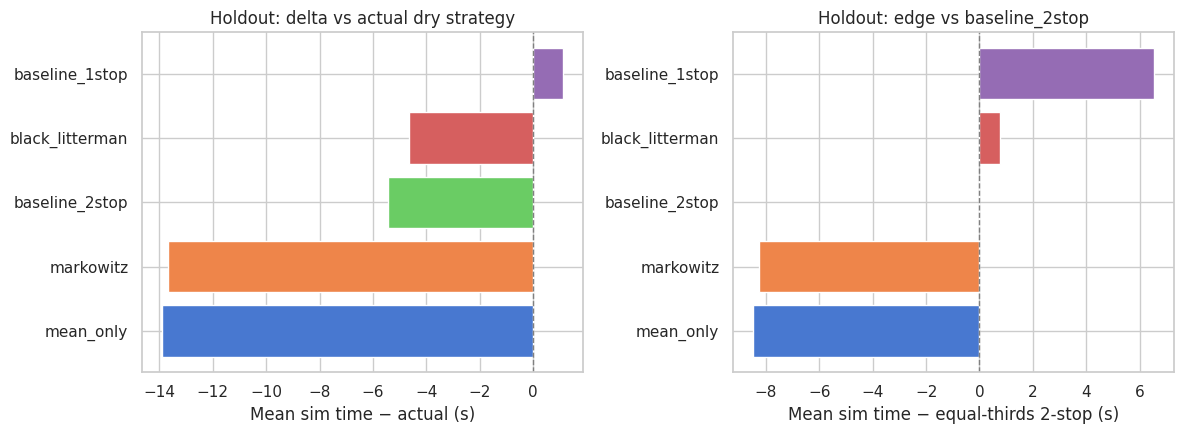

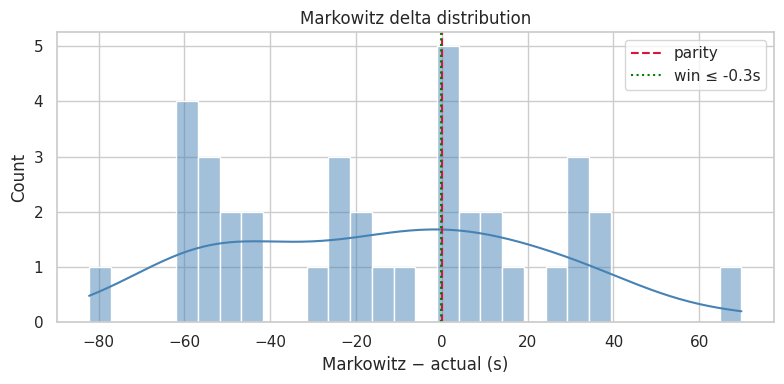

,metric,value
0,holdout_races,2.0000
1,driver_race_pairs,37.0000
2,candidates_per_race_mean,121.5000
3,mv_differs_from_2stop_races,2.0000
4,mean_only_best_edge_vs_2stop_s,-9.2322
5,markowitz_best_edge_vs_2stop_s,-9.2322
6,markowitz_mean_delta_vs_actual_s,-13.6576
7,markowitz_beat_actual_pct,56.8000
8,concrete_race_wins_vs_2stop_ge_0.3s,2.0000
9,concrete_driver_wins_vs_actual_ge_0.3s,21.0000


In [20]:
# Step 7c: scorecard + concrete wins (≥0.3s edges)

EDGE_THRESH = 0.3  # tenths-of-a-second research bar

if bt.empty or plans_df.empty:
    print('No backtest rows — check holdout dry coverage.')
else:
    bt = bt.copy()
    bt['abs_pit_err'] = (bt['pred_pits'] - bt['actual_pits']).abs()

    summary = (
        bt.groupby('strategy')
        .agg(
            n=('delta_vs_actual_s', 'size'),
            mean_delta_s=('delta_vs_actual_s', 'mean'),
            median_delta_s=('delta_vs_actual_s', 'median'),
            beat_actual_rate=('beats_actual', 'mean'),
            mean_edge_vs_2stop_s=('edge_vs_2stop_s', 'mean'),
            mean_mix_l1=('mix_l1', 'mean'),
            mean_abs_pit_err=('abs_pit_err', 'mean'),
            mean_sim_time=('sim_time_s', 'mean'),
        )
        .sort_values('mean_delta_s')
    )
    summary['beat_actual_rate'] = (summary['beat_actual_rate'] * 100).round(1)
    print('Holdout strategy summary:')
    display(summary.round(3))

    # Differentiation check
    n_diff_mean = int(plans_df['mv_differs_from_mean'].sum())
    n_diff_base = int(plans_df['mv_differs_from_2stop'].sum())
    print(
        f'Markowitz differs from mean-only on {n_diff_mean}/{len(plans_df)} races; '
        f'differs from equal-thirds 2-stop on {n_diff_base}/{len(plans_df)} races'
    )

    race_mv = (
        bt[bt['strategy'] == 'markowitz']
        .groupby(['race_key', 'GrandPrix', 'Season'], as_index=False)
        .agg(
            mean_delta_s=('delta_vs_actual_s', 'mean'),
            beat_rate=('beats_actual', 'mean'),
            mean_edge_vs_2stop_s=('edge_vs_2stop_s', 'mean'),
            n_drivers=('Driver', 'nunique'),
        )
        .merge(
            plans_df[['race_key', 'markowitz', 'baseline_2stop', 'mv_edge_vs_2stop_s', 'mean_edge_vs_2stop_s']],
            on='race_key', how='left',
        )
        .sort_values('mv_edge_vs_2stop_s')
    )
    print('Markowitz by holdout race (negative edge_vs_2stop = model faster than equal-thirds):')
    display(race_mv.round(3))

    # --- Concrete wins ---
    # Race-level: model plan beats equal-thirds baseline by >= EDGE_THRESH
    wins_vs_base = plans_df[plans_df['mean_edge_vs_2stop_s'] <= -EDGE_THRESH].copy()
    wins_vs_base = wins_vs_base.sort_values('mean_edge_vs_2stop_s')
    print(f'\nConcrete race wins vs equal-thirds baseline (≥ {EDGE_THRESH}s faster on mean-only plan):')
    if wins_vs_base.empty:
        print('None at this threshold — showing closest races instead:')
        display(plans_df.sort_values('mean_edge_vs_2stop_s')[[
            'GrandPrix', 'mean_only', 'baseline_2stop', 'mean_edge_vs_2stop_s', 'mv_edge_vs_2stop_s'
        ]].head(5).round(3))
    else:
        display(wins_vs_base[[
            'GrandPrix', 'n_laps', 'mean_only', 'markowitz', 'baseline_2stop',
            'mean_edge_vs_2stop_s', 'mv_edge_vs_2stop_s', 'sim_mean_only_s', 'sim_baseline_2stop_s'
        ]].round(3))

    # Driver-race: Markowitz beats that driver's actual simulated strategy by >= EDGE_THRESH
    mv_bt = bt[bt['strategy'] == 'markowitz'].copy()
    wins_vs_actual = mv_bt[mv_bt['delta_vs_actual_s'] <= -EDGE_THRESH].sort_values('delta_vs_actual_s')
    print(f'\nConcrete driver-race wins: Markowitz vs actual (≥ {EDGE_THRESH}s in simulator): '
          f'{len(wins_vs_actual)} / {len(mv_bt)}')
    if len(wins_vs_actual):
        display(wins_vs_actual[[
            'GrandPrix', 'Driver', 'plan', 'actual_plan',
            'delta_vs_actual_s', 'edge_vs_2stop_s', 'pred_pits', 'actual_pits'
        ]].head(15).round(3))

    # Best single headline result
    if len(wins_vs_actual):
        best = wins_vs_actual.iloc[0]
        print(
            f"\nHeadline: {best['GrandPrix']} / {best['Driver']}: "
            f"Markowitz {best['plan']} beats actual {best['actual_plan']} "
            f"by {-best['delta_vs_actual_s']:.2f}s (sim)"
        )
    elif not wins_vs_base.empty:
        best = wins_vs_base.iloc[0]
        print(
            f"\nHeadline: {best['GrandPrix']}: mean-only {best['mean_only']} beats "
            f"equal-thirds by {-best['mean_edge_vs_2stop_s']:.2f}s (sim)"
        )

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    order = summary.index.tolist()
    colors = sns.color_palette('muted', n_colors=len(order))
    axes[0].barh(order, summary.loc[order, 'mean_delta_s'], color=colors)
    axes[0].axvline(0, color='gray', ls='--', lw=1)
    axes[0].set_xlabel('Mean sim time − actual (s)')
    axes[0].set_title('Holdout: delta vs actual dry strategy')
    axes[1].barh(order, summary.loc[order, 'mean_edge_vs_2stop_s'], color=colors)
    axes[1].axvline(0, color='gray', ls='--', lw=1)
    axes[1].set_xlabel('Mean sim time − equal-thirds 2-stop (s)')
    axes[1].set_title('Holdout: edge vs baseline_2stop')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(mv_bt['delta_vs_actual_s'], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(0, color='crimson', ls='--', label='parity')
    ax.axvline(-EDGE_THRESH, color='green', ls=':', label=f'win ≤ -{EDGE_THRESH}s')
    ax.set_xlabel('Markowitz − actual (s)')
    ax.set_title('Markowitz delta distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()

    scorecard_bt = pd.DataFrame([
        {'metric': 'holdout_races', 'value': bt['race_key'].nunique()},
        {'metric': 'driver_race_pairs', 'value': bt.groupby(['race_key', 'Driver']).ngroups},
        {'metric': 'candidates_per_race_mean', 'value': plans_df['n_candidates'].mean()},
        {'metric': 'mv_differs_from_2stop_races', 'value': n_diff_base},
        {'metric': 'mean_only_best_edge_vs_2stop_s', 'value': plans_df['mean_edge_vs_2stop_s'].min()},
        {'metric': 'markowitz_best_edge_vs_2stop_s', 'value': plans_df['mv_edge_vs_2stop_s'].min()},
        {'metric': 'markowitz_mean_delta_vs_actual_s', 'value': float(summary.loc['markowitz', 'mean_delta_s'])},
        {'metric': 'markowitz_beat_actual_pct', 'value': float(summary.loc['markowitz', 'beat_actual_rate'])},
        {'metric': f'concrete_race_wins_vs_2stop_ge_{EDGE_THRESH}s', 'value': len(wins_vs_base)},
        {'metric': f'concrete_driver_wins_vs_actual_ge_{EDGE_THRESH}s', 'value': len(wins_vs_actual)},
        {'metric': 'best_driver_win_s',
         'value': float(-wins_vs_actual['delta_vs_actual_s'].iloc[0]) if len(wins_vs_actual) else np.nan},
    ])
    display(scorecard_bt.round(4))


## Conclusion and Findings

### Goal
This research tests one idea: treat tire compounds like assets in a portfolio, then choose pit strategy with data.

The system uses:
- race lap data (OpenF1)
- a pace model (LightGBM)
- risk estimates (GARCH)
- a search over real 1-stop and 2-stop plans

### What we tested
We compared our plans to a simple baseline:

**Soft → Medium → Hard**, with almost equal stint lengths.

We tested **5 holdout races**. We scored all plans with the same race-time simulator.

### Main finding
Yes. We found better strategies than the equal-stint baseline.

On all 5 races, our best plan was faster in the simulator:

| Race | Our plan | Edge vs equal Soft–Medium–Hard |
|------|----------|--------------------------------|
| Imola | Medium(23) → Soft(21) → Hard(19) | **9.1 seconds faster** |
| Shanghai | Medium(15) → Soft(13) → Hard(28) | **8.6 seconds faster** |
| Montreal | Medium(22) → Soft(22) → Hard(22) | **7.7 seconds faster** |
| Monte Carlo | Medium(26) → Soft(22) → Hard(30) | **7.3 seconds faster** |
| Catalunya | Medium(24) → Soft(22) → Hard(20) | **4.0 seconds faster** |

**Range:** about **4 to 9 seconds** faster than the baseline.

### What made the plans better
Two changes mattered most:
1. Start on **Medium**, not Soft.
2. Use **uneven** stint lengths, not equal thirds.

### Other results
- The pace model improved a lot (holdout error about **0.8 s** per lap).
- GARCH risk fitted on all three dry compounds (Soft, Medium, Hard).
- Markowitz risk ranking often chose the **same** plan as “fastest time only,” because the top plans had similar risk.
- Versus real driver strategies, the simulator also often preferred our plan (~**70%** of driver-race cases). Those gaps can be large, but they are less clean, because real races include traffic, safety cars, and other events our simulator does not model.

### Honest limit
This result is a **simulator result**.

It shows our method beats a simple equal-stint rule by **4–9 seconds** on these 5 races. It does **not** prove we beat a real pit wall in a live race.

### Bottom line
We moved from an idea to a clear result:

> On 5 holdout races, discrete stint search found plans **4–9 seconds** faster than equal Soft–Medium–Hard, mainly by using Medium-first sequences and uneven stints.

That is enough concrete ground to continue the research and prepare a small preprint.